This mirrored rolling notebook keeps the visible view-config pattern from the normalized Baltic workflow, but now renders through the typed real-data notebook helper instead of committed smoke fixtures.


In [8]:
from __future__ import annotations

from copy import deepcopy
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
for candidate in (project_root, *project_root.parents):
    if (candidate / "macro_indicator_v2").exists():
        project_root = candidate
        break
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from macro_indicator_v2.infrastructure.notebook import (
    render_real_country_notebook_section,
    resolve_project_root,
)


In [9]:
project_root = resolve_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

project_subdir = project_root / "bs2026_student_projects" / "Arturas_Sotnicenko_v2"
rolling_output_root = project_subdir / "outputs_baltics_rolling_10y_v2"
country_codes = ("LT", "LV", "EE")


## View config contract

The mirrored `v2` notebook keeps explicit visible config objects for the presentation and methodology views, then translates those visible notebook values into typed requests at the adapter boundary.


In [10]:
def _build_recommended_gdp_growth_transformation_strategy(*, include_nominal_gdp: bool = False):
    strategy = {
        "harmonization": {"mode": "built_in"},
        "analytical": {
            "method": "none",
            "keep_original": True,
            "indicator_overrides": {
                "gdp_per_capita": {
                    "method": "log_diff_yoy",
                    "emit_indicator_id": "gdp_per_capita_yoy_log_pct",
                    "indicator_name": "GDP per capita growth",
                    "specificity": "Annual log growth, %",
                    "unit": "percent",
                    "keep_original": True,
                },
                "real_gdp": {
                    "method": "log_diff_yoy",
                    "emit_indicator_id": "real_gdp_yoy_log_pct",
                    "indicator_name": "Real GDP growth",
                    "specificity": "Annual log growth, %",
                    "unit": "percent",
                    "keep_original": True,
                },
            },
        },
    }
    if include_nominal_gdp:
        strategy["analytical"]["indicator_overrides"] = deepcopy(
            strategy["analytical"]["indicator_overrides"]
        )
        strategy["analytical"]["indicator_overrides"]["gdp_current_usd"] = {
            "method": "log_diff_yoy",
            "emit_indicator_id": "gdp_current_usd_yoy_log_pct",
            "indicator_name": "Nominal GDP growth",
            "specificity": "Annual log growth, %",
            "unit": "percent",
            "keep_original": True,
        }
    return strategy


rolling_normalization_config = {
    "mode": "rolling_trailing",
    "rolling_window_years": 10,
    "exclude_current_from_window": True,
    "min_obs_for_zscore": 5,
}

presentation_view_config = {
    "view_name": "presentation_view",
    "normalization_config": deepcopy(rolling_normalization_config),
    "transformation_strategy": _build_recommended_gdp_growth_transformation_strategy(),
    "region_label": "Baltics presentation",
    "force_refresh": True,
    "indicator_groups": {
        "Growth narrative": [
            "real_gdp_yoy_log_pct",
            "gdp_per_capita_yoy_log_pct",
            "inflation_cpi_yoy",
        ],
        "Context": ["general_government_gross_debt_pct_gdp"],
    },
    "show_sections": True,
    "show_manifest": False,
    "show_labels": False,
}
methodology_view_config = {
    "view_name": "methodology_view",
    "normalization_config": deepcopy(rolling_normalization_config),
    "transformation_strategy": None,
    "region_label": "Baltics methodology",
    "force_refresh": True,
    "indicator_groups": {
        "Output and growth": ["real_gdp", "gdp_per_capita", "gdp_current_usd"],
        "Inflation and prices": ["inflation_cpi_yoy"],
        "Fiscal indicators": ["general_government_gross_debt_pct_gdp"],
    },
    "show_sections": True,
    "show_manifest": True,
    "show_labels": True,
}
notebook_view_configs = {
    "presentation": presentation_view_config,
    "methodology": methodology_view_config,
}

active_notebook_view_name = "methodology"
active_notebook_view_config = notebook_view_configs[active_notebook_view_name]
_USE_CURRENT_NOTEBOOK_DEFAULT = object()

normalization_config = active_notebook_view_config["normalization_config"]
transformation_strategy = active_notebook_view_config["transformation_strategy"]
normalized_region_label = active_notebook_view_config["region_label"]
force_zscore_refresh = active_notebook_view_config["force_refresh"]
indicator_groups = active_notebook_view_config["indicator_groups"]

print(f"Active notebook view: {active_notebook_view_name}")
print(f"Active normalization enabled: {normalization_config is not None}")
print(f"Active transformation enabled: {transformation_strategy is not None}")


Active notebook view: methodology
Active normalization enabled: True
Active transformation enabled: False


In [11]:
def _render_country_rolling_section(
    country_code: str,
    *,
    view_name: str,
    view_config: dict[str, object] | None = None,
    normalization_config=_USE_CURRENT_NOTEBOOK_DEFAULT,
    transformation_strategy=_USE_CURRENT_NOTEBOOK_DEFAULT,
    region_label=_USE_CURRENT_NOTEBOOK_DEFAULT,
    force_refresh=_USE_CURRENT_NOTEBOOK_DEFAULT,
    indicator_groups=_USE_CURRENT_NOTEBOOK_DEFAULT,
):
    effective_view_config = active_notebook_view_config if view_config is None else view_config
    effective_normalization_config = (
        effective_view_config["normalization_config"]
        if normalization_config is _USE_CURRENT_NOTEBOOK_DEFAULT
        else normalization_config
    )
    effective_transformation_strategy = (
        effective_view_config["transformation_strategy"]
        if transformation_strategy is _USE_CURRENT_NOTEBOOK_DEFAULT
        else transformation_strategy
    )
    effective_region_label = (
        effective_view_config["region_label"]
        if region_label is _USE_CURRENT_NOTEBOOK_DEFAULT
        else region_label
    )
    effective_force_refresh = (
        effective_view_config["force_refresh"]
        if force_refresh is _USE_CURRENT_NOTEBOOK_DEFAULT
        else force_refresh
    )
    effective_indicator_groups = (
        effective_view_config["indicator_groups"]
        if indicator_groups is _USE_CURRENT_NOTEBOOK_DEFAULT
        else indicator_groups
    )

    run = render_real_country_notebook_section(
        country_code=country_code,
        country_output_dir=rolling_output_root / country_code / view_name,
        normalization_config=effective_normalization_config,
        transformation_strategy=effective_transformation_strategy,
        region_label=effective_region_label,
        force_refresh=effective_force_refresh,
        indicator_groups=effective_indicator_groups,
        project_root=project_root,
        include_analysis=True,
        reuse_existing=not effective_force_refresh,
        show_sections=bool(effective_view_config.get("show_sections", True)),
        show_manifest=bool(effective_view_config.get("show_manifest", True)),
        show_labels=bool(effective_view_config.get("show_labels", False)),
        show_visuals=True,
    )
    return run.notebook_view


## Presentation view

The presentation view keeps the rolling normalization plus GDP-growth transformation setup visible in notebook config, then renders the transformed `v2` view for each Baltic country.


### Lithuania

- Render: Lithuania | dynamic notebook | region Baltics presentation

- Normalization: Rolling trailing, 10y, exclude current, min obs 5

- Transformation: Transformation active: GDP per capita growth, Real GDP growth

,country_code,country_display_name,render_origin,region_label,normalization,transformation,manifest_path,anomalies_path
0,LT,Lithuania,dynamic_notebook,Baltics presentation,"Rolling trailing, 10y, exclude current, min obs 5","Transformation active: GDP per capita growth, ...",/workspaces/da-ai-v2/bs2026_student_projects/A...,/workspaces/da-ai-v2/bs2026_student_projects/A...


#### Indicator sections

,group_name,indicator_ids
0,Context,general_government_gross_debt_pct_gdp
1,Growth narrative,"real_gdp_yoy_log_pct, gdp_per_capita_yoy_log_p..."
2,Remaining,"exchange_rate_lcu_per_usd, gdp_current_usd, gd..."


#### Chart artifacts

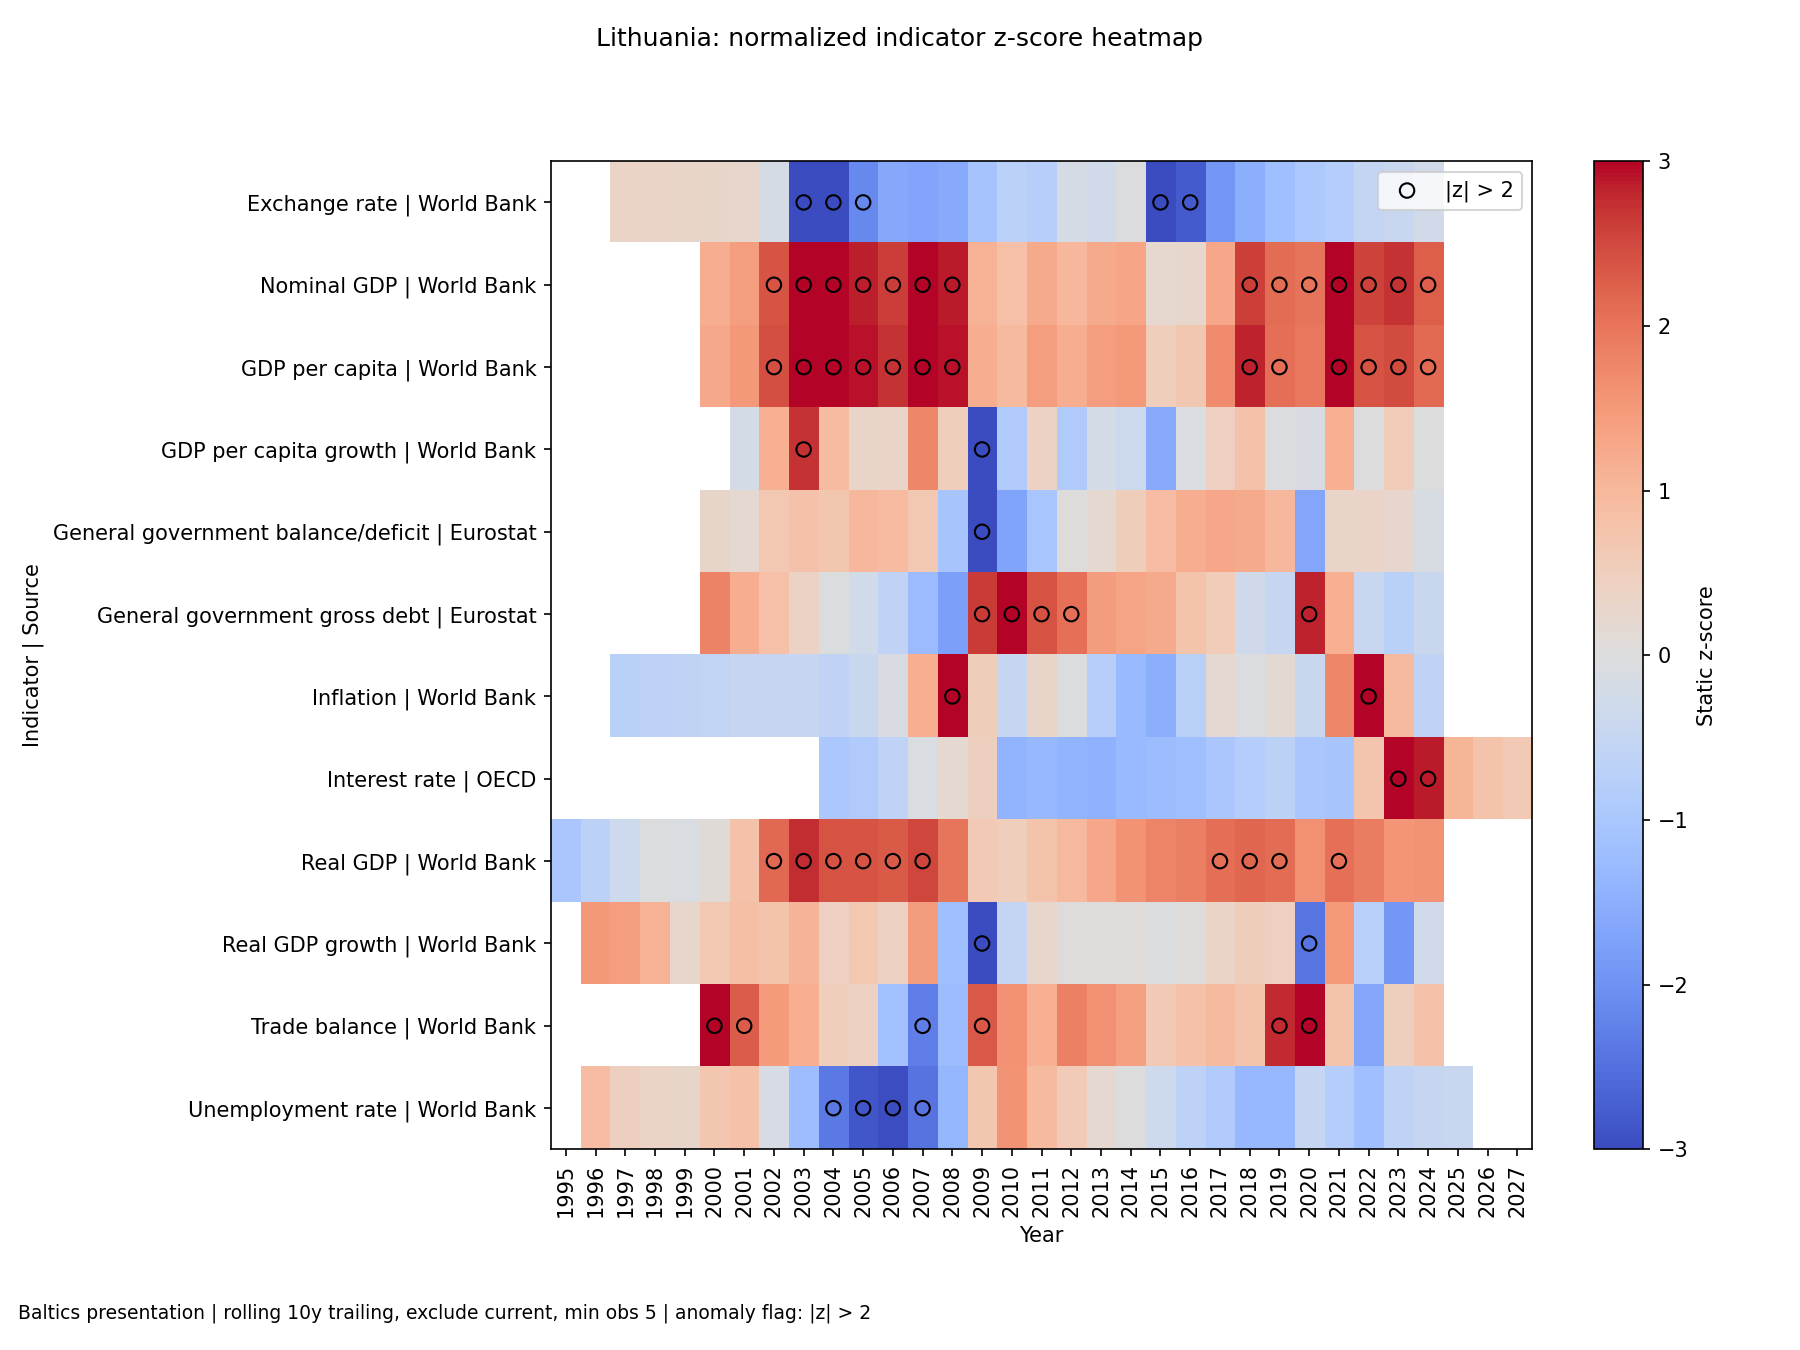

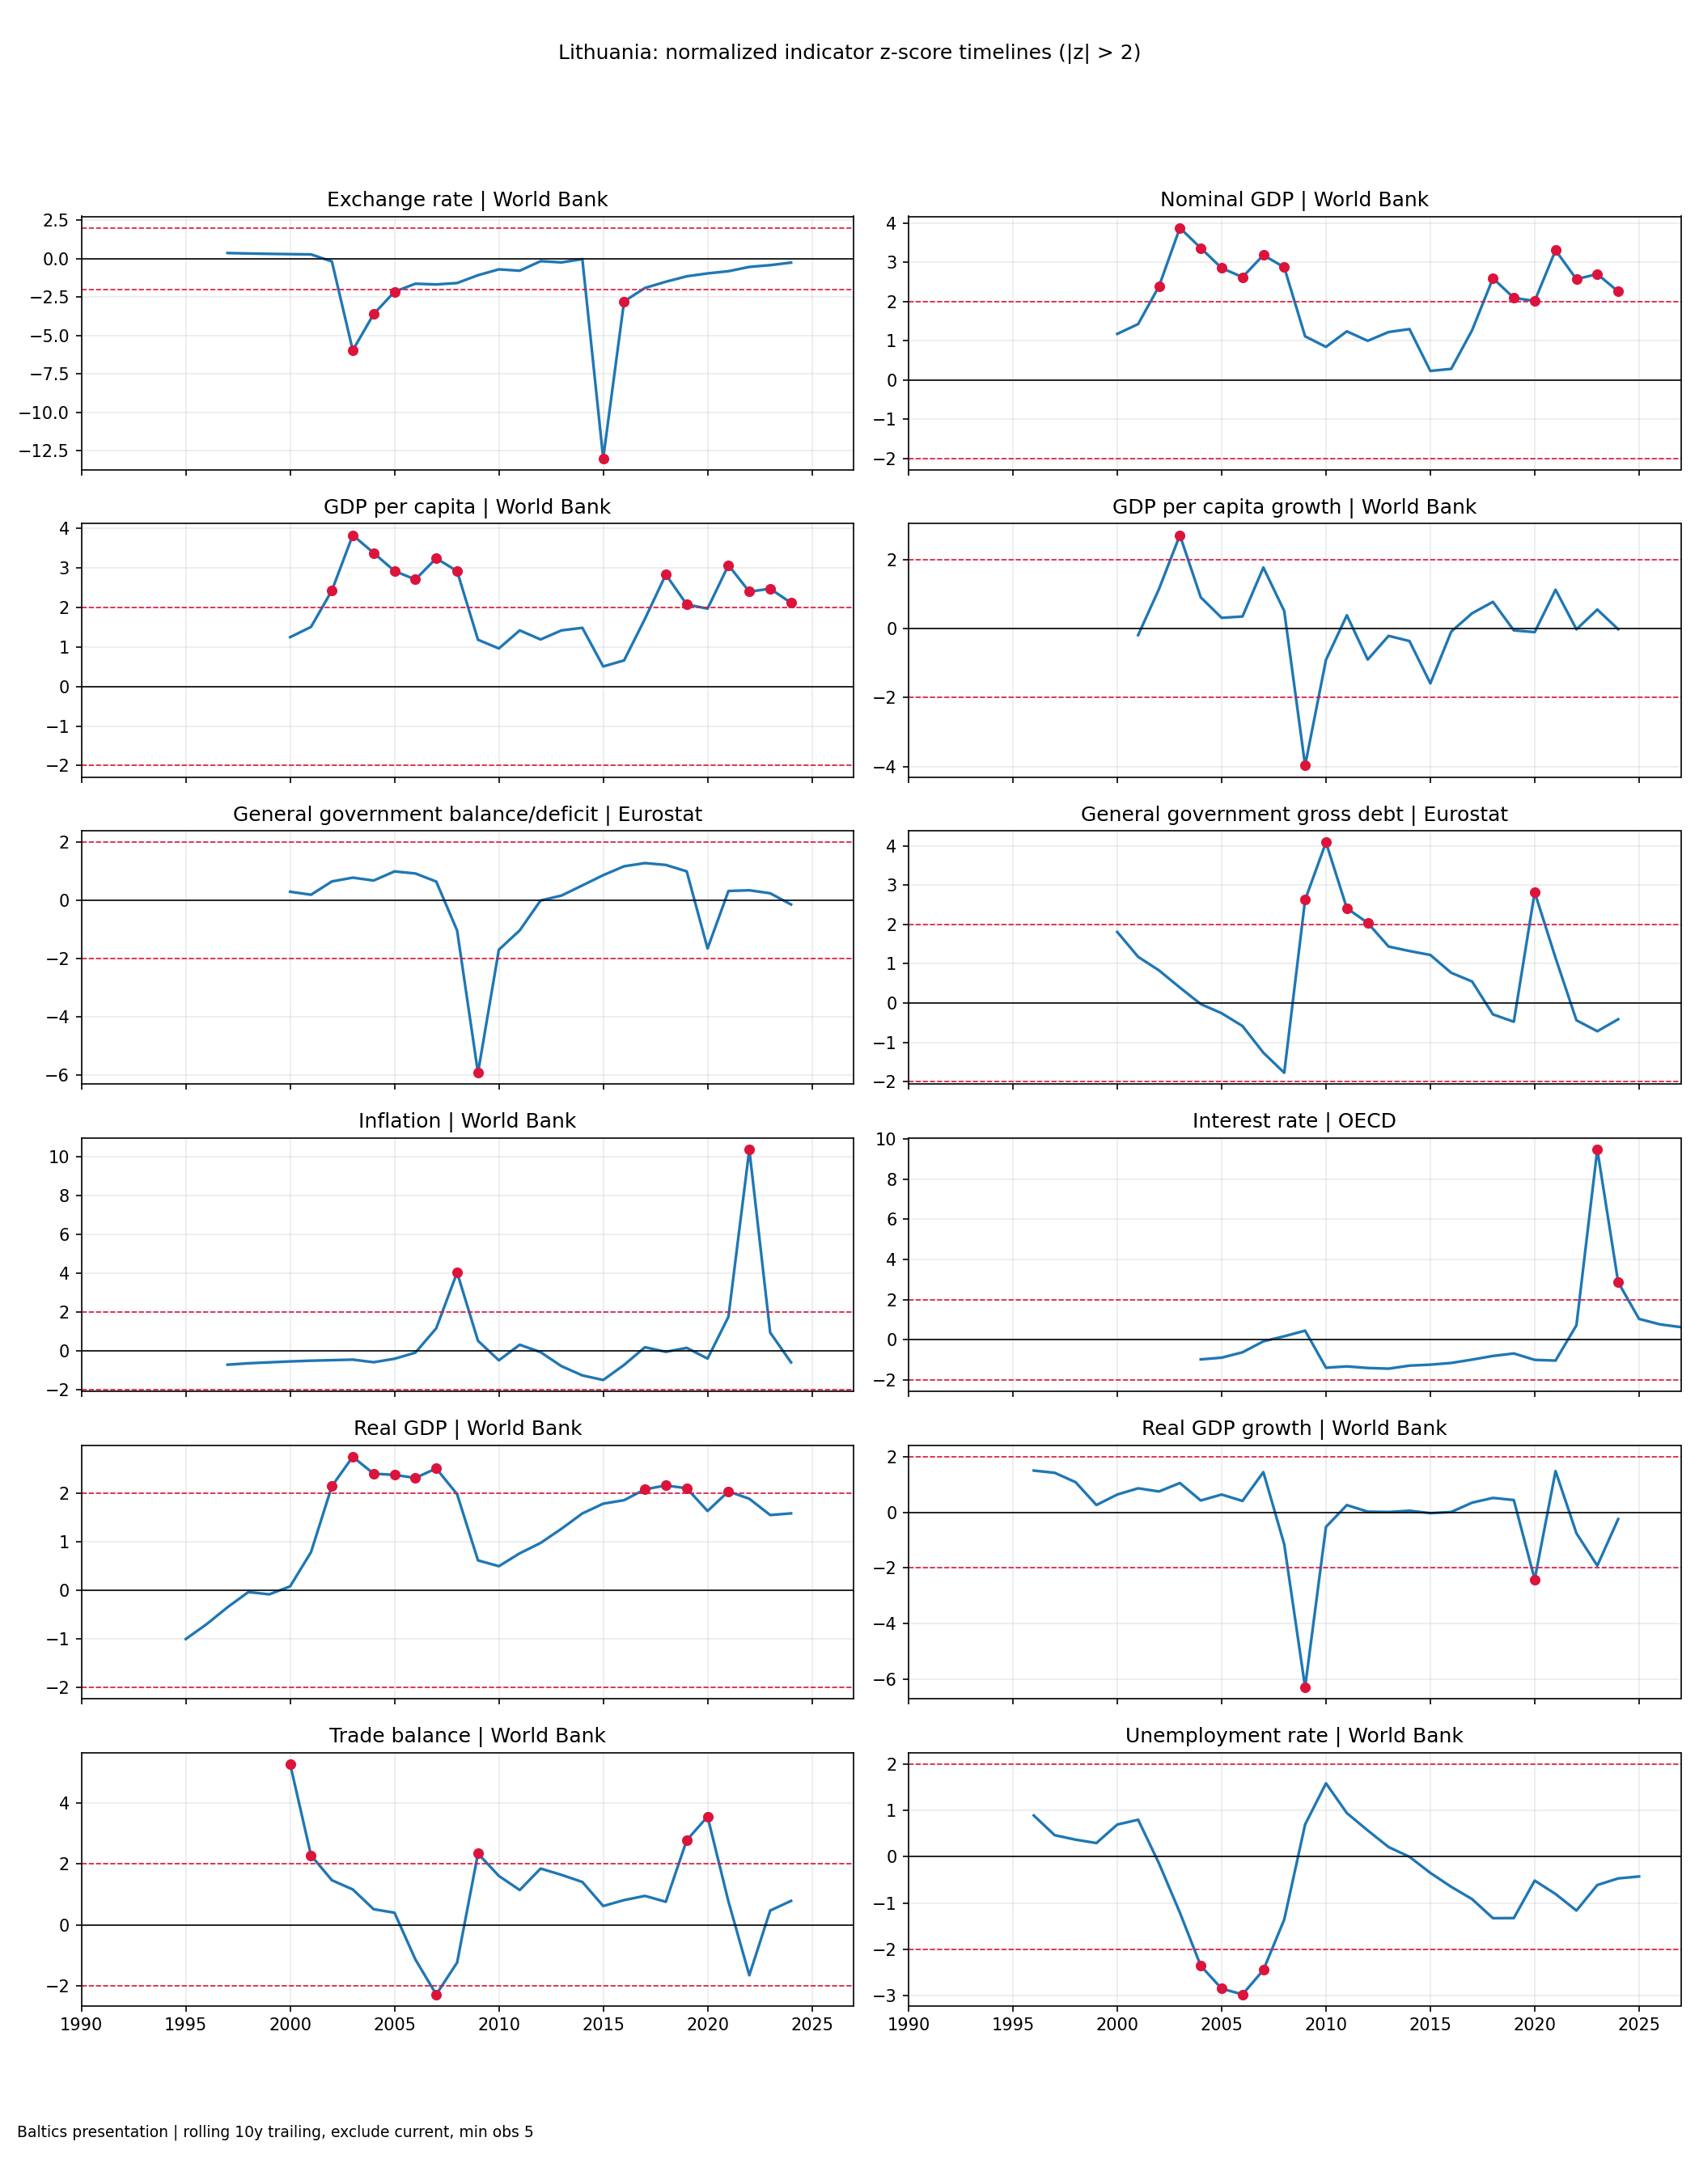

### Latvia

- Render: Latvia | dynamic notebook | region Baltics presentation

- Normalization: Rolling trailing, 10y, exclude current, min obs 5

- Transformation: Transformation active: GDP per capita growth, Real GDP growth

,country_code,country_display_name,render_origin,region_label,normalization,transformation,manifest_path,anomalies_path
0,LV,Latvia,dynamic_notebook,Baltics presentation,"Rolling trailing, 10y, exclude current, min obs 5","Transformation active: GDP per capita growth, ...",/workspaces/da-ai-v2/bs2026_student_projects/A...,/workspaces/da-ai-v2/bs2026_student_projects/A...


#### Indicator sections

,group_name,indicator_ids
0,Context,general_government_gross_debt_pct_gdp
1,Growth narrative,"real_gdp_yoy_log_pct, gdp_per_capita_yoy_log_p..."
2,Remaining,"exchange_rate_lcu_per_usd, gdp_current_usd, gd..."


#### Chart artifacts

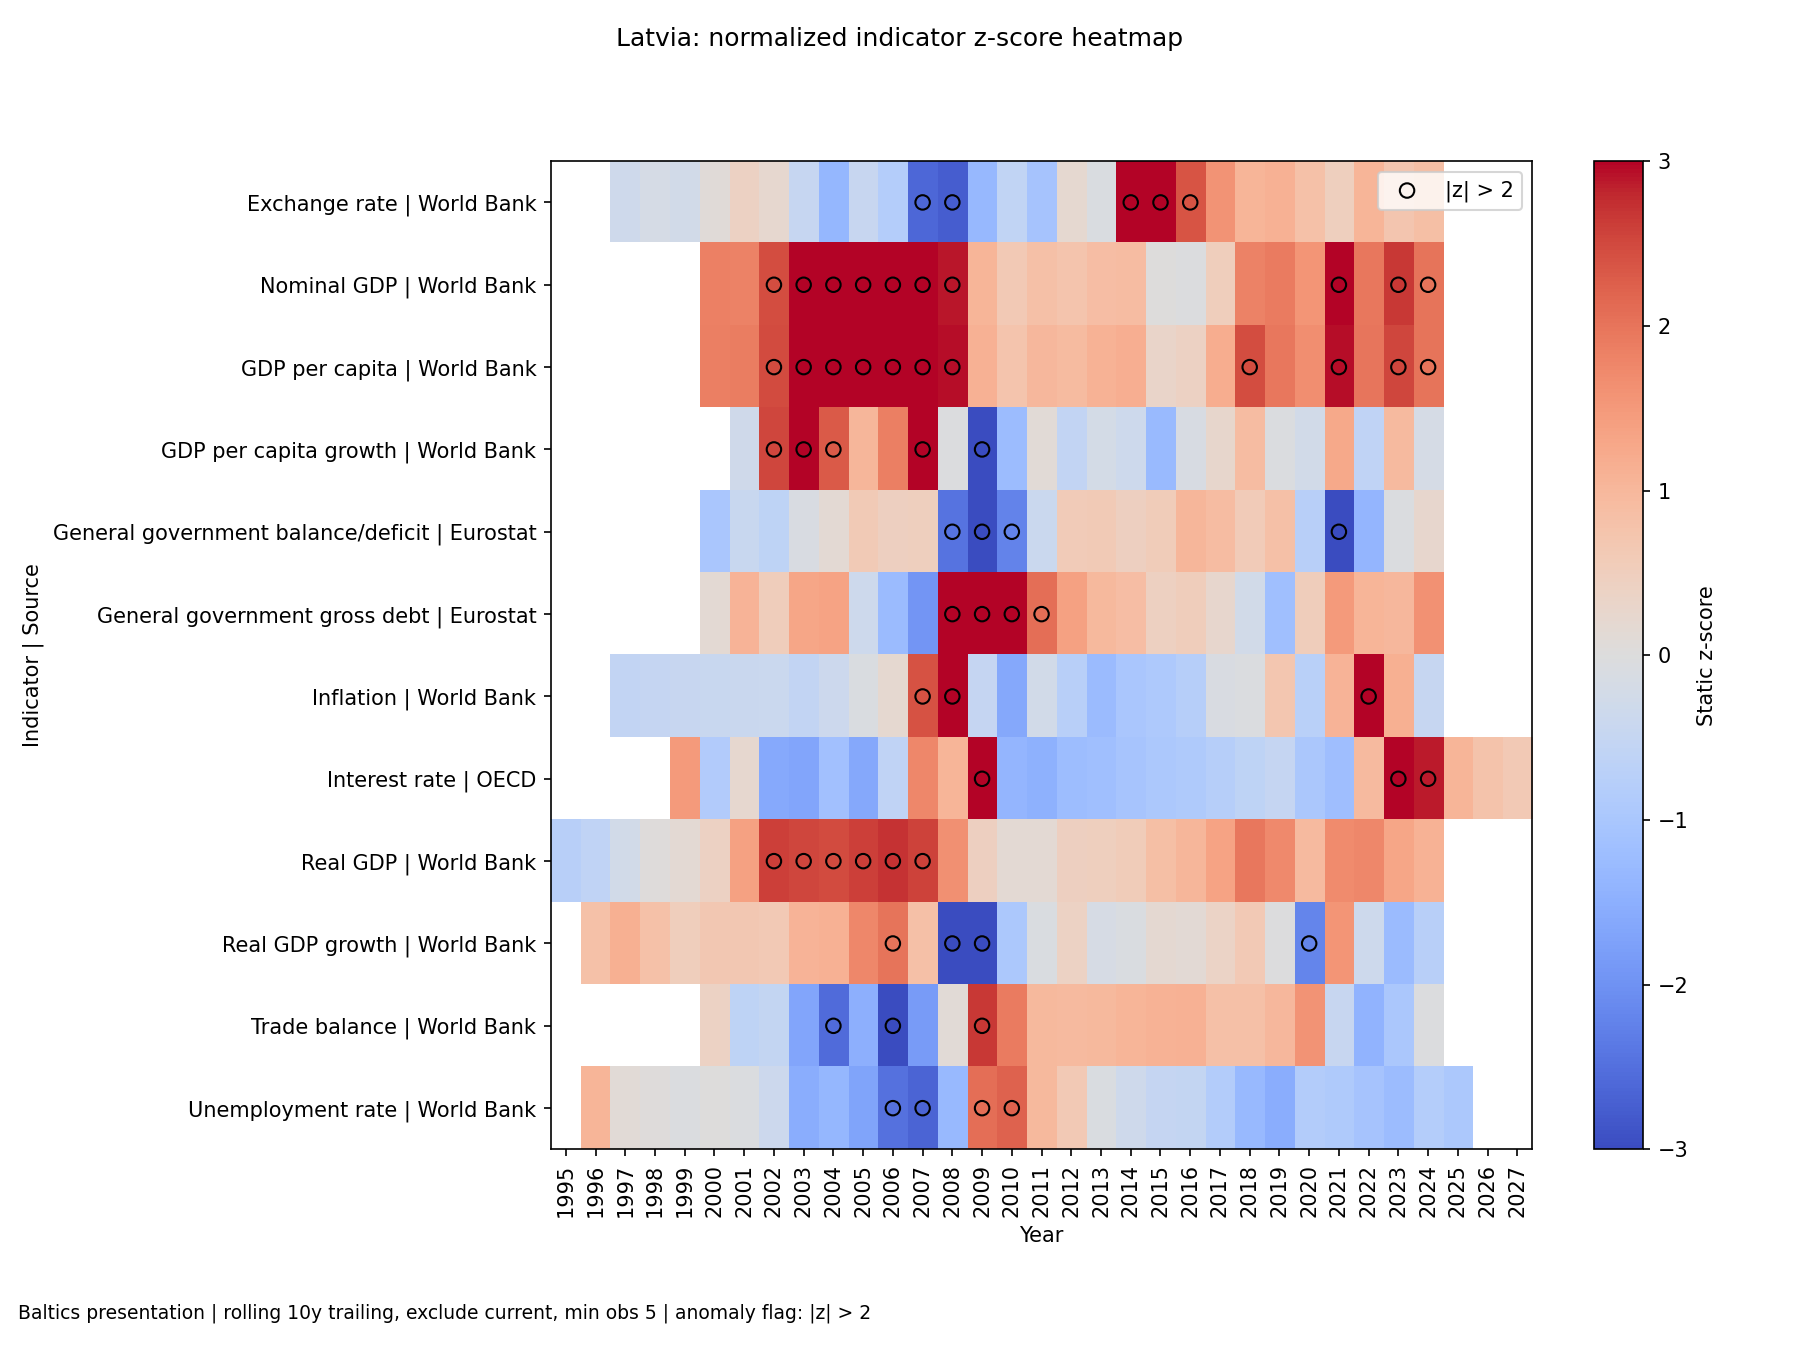

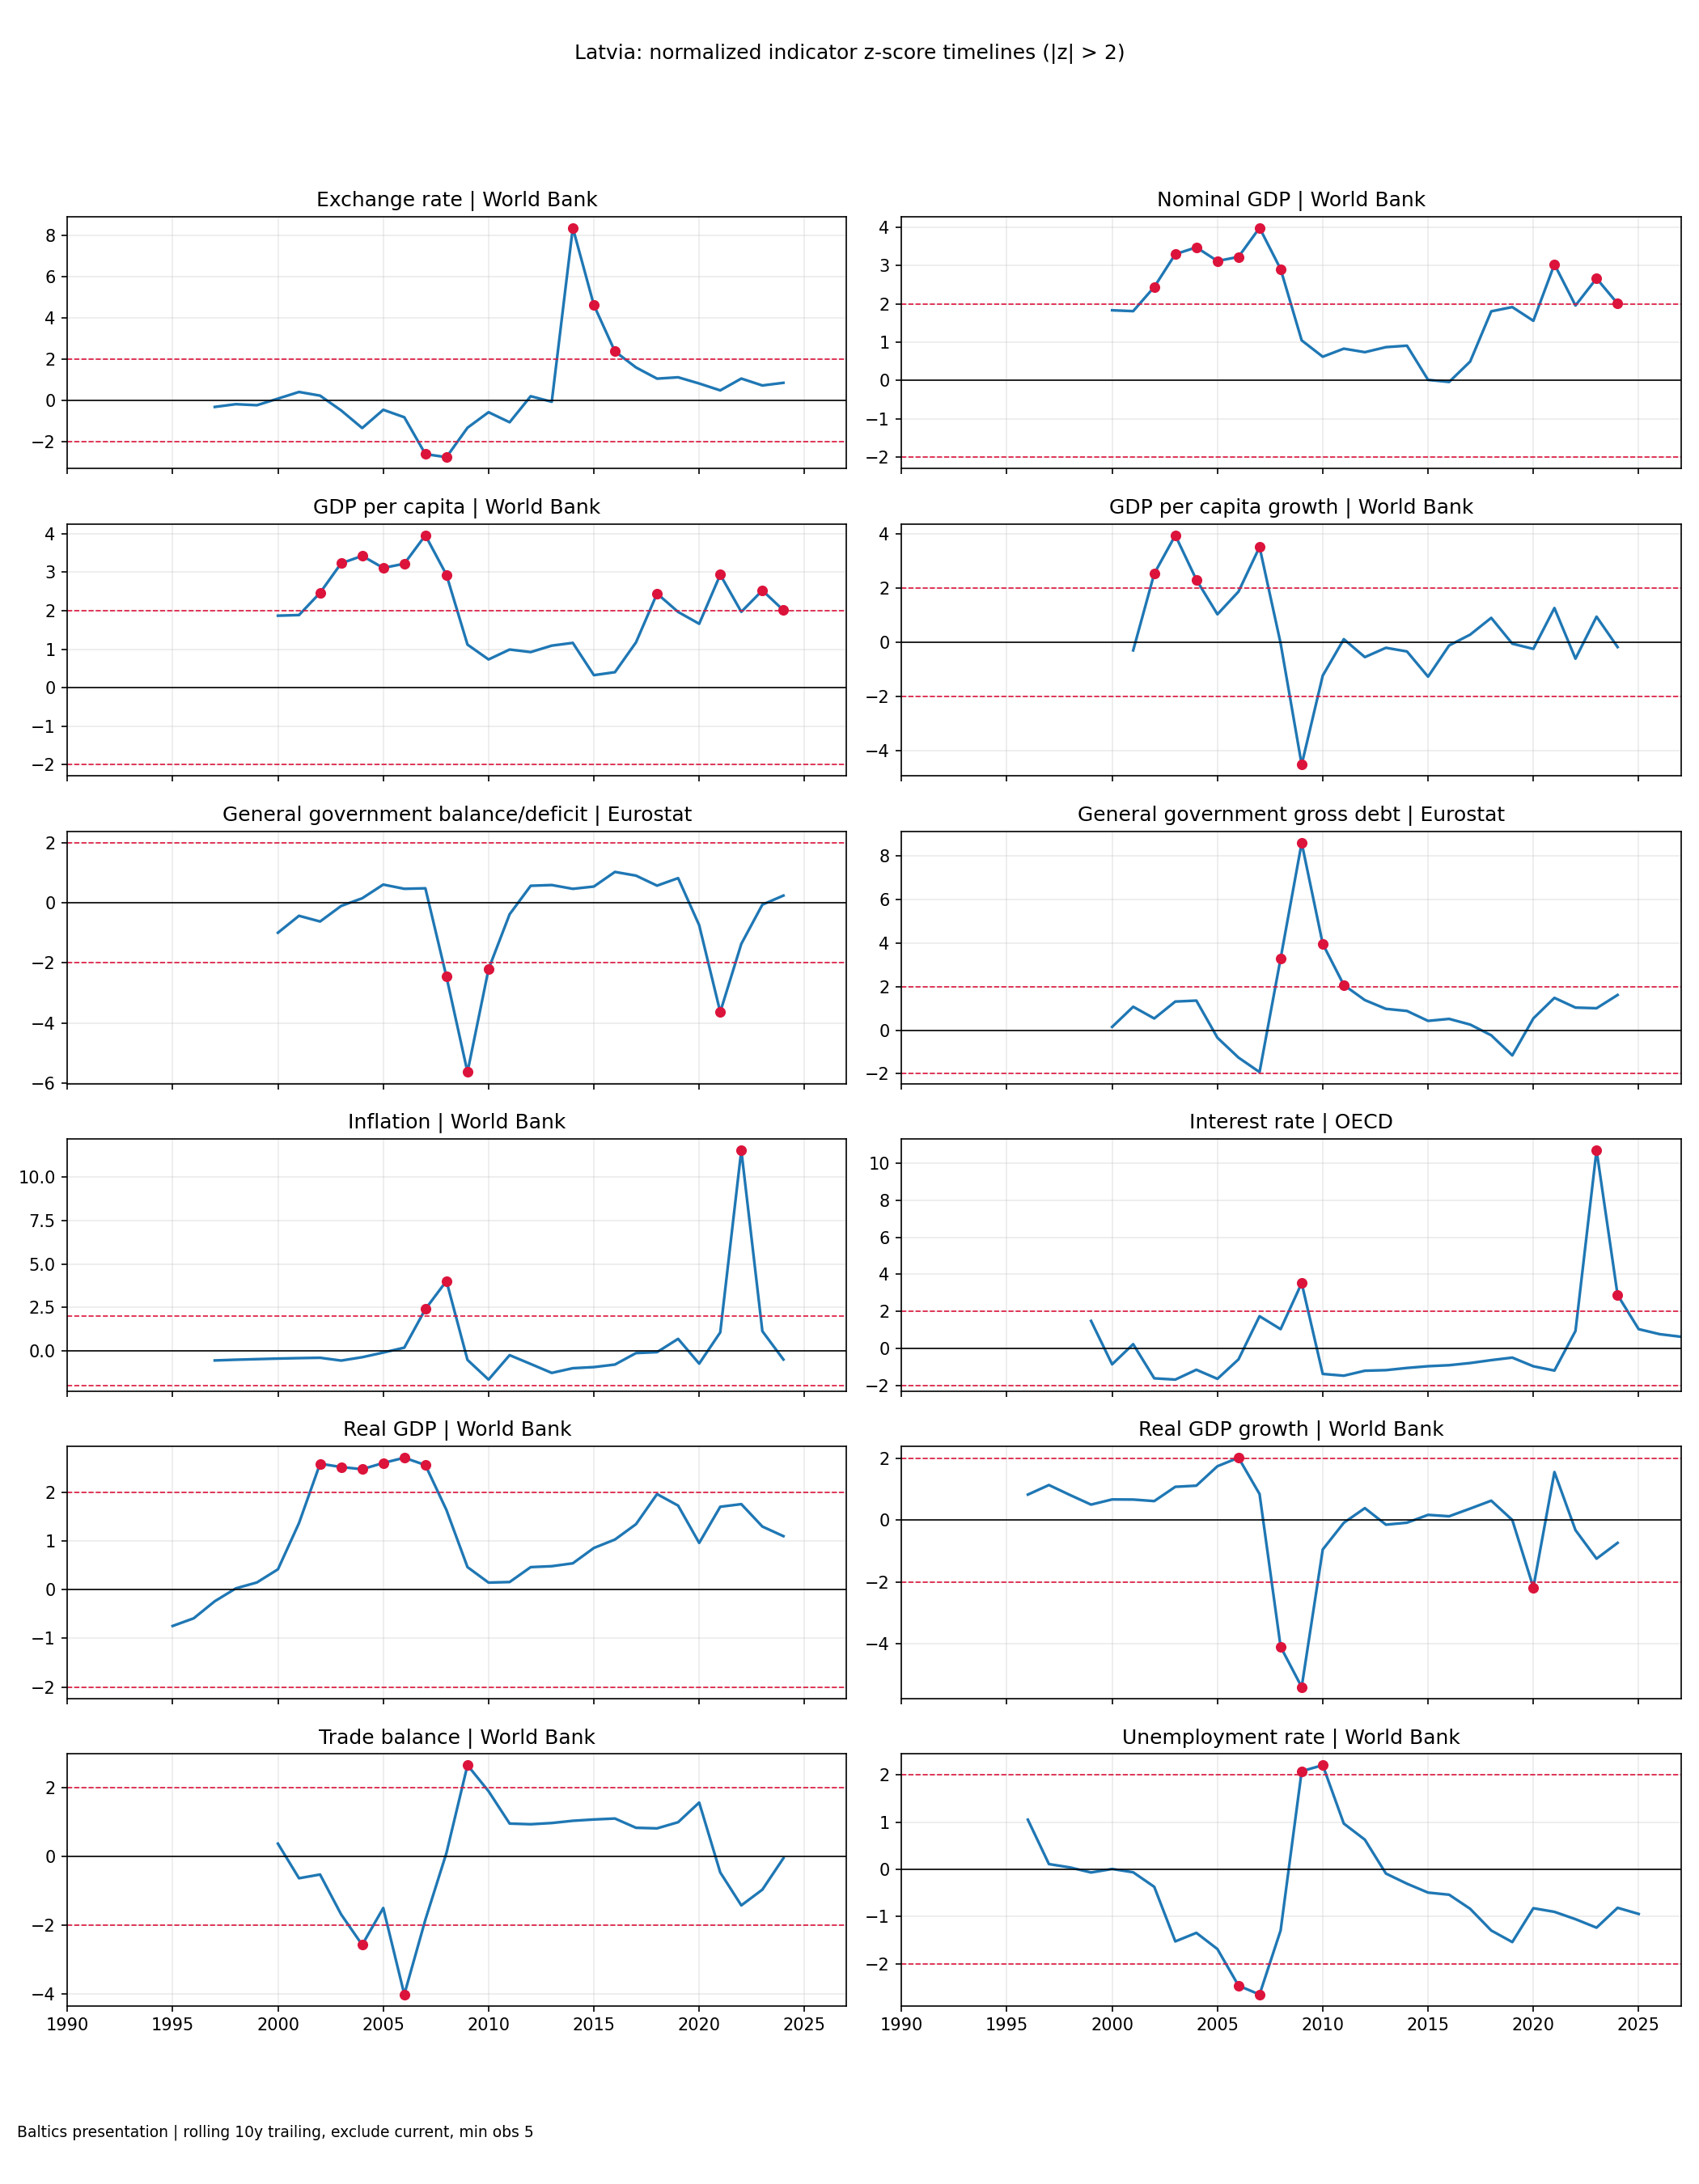

### Estonia

- Render: Estonia | dynamic notebook | region Baltics presentation

- Normalization: Rolling trailing, 10y, exclude current, min obs 5

- Transformation: Transformation active: GDP per capita growth, Real GDP growth

,country_code,country_display_name,render_origin,region_label,normalization,transformation,manifest_path,anomalies_path
0,EE,Estonia,dynamic_notebook,Baltics presentation,"Rolling trailing, 10y, exclude current, min obs 5","Transformation active: GDP per capita growth, ...",/workspaces/da-ai-v2/bs2026_student_projects/A...,/workspaces/da-ai-v2/bs2026_student_projects/A...


#### Indicator sections

,group_name,indicator_ids
0,Context,general_government_gross_debt_pct_gdp
1,Growth narrative,"real_gdp_yoy_log_pct, gdp_per_capita_yoy_log_p..."
2,Remaining,"exchange_rate_lcu_per_usd, gdp_current_usd, gd..."


#### Chart artifacts

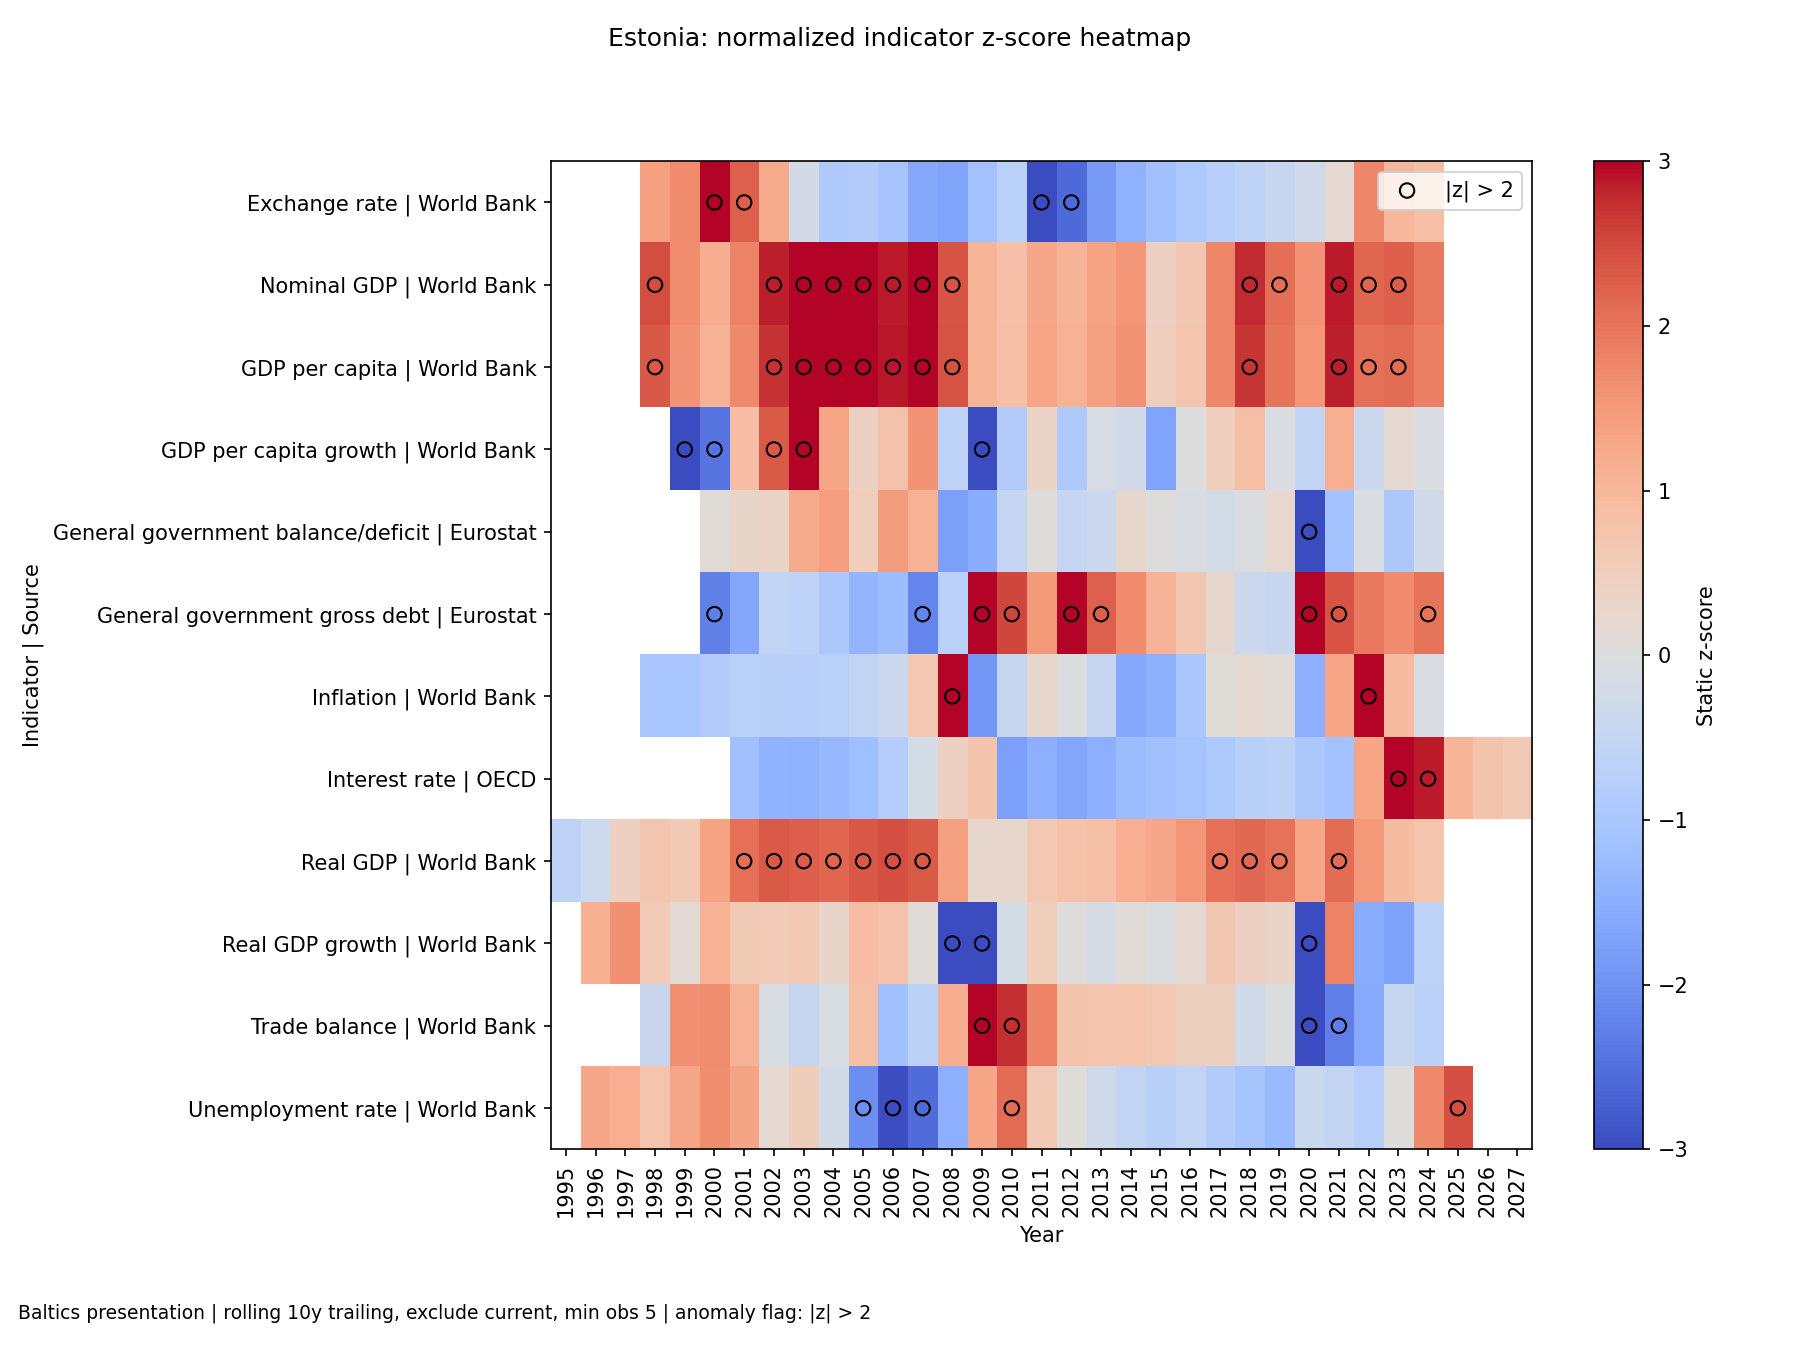

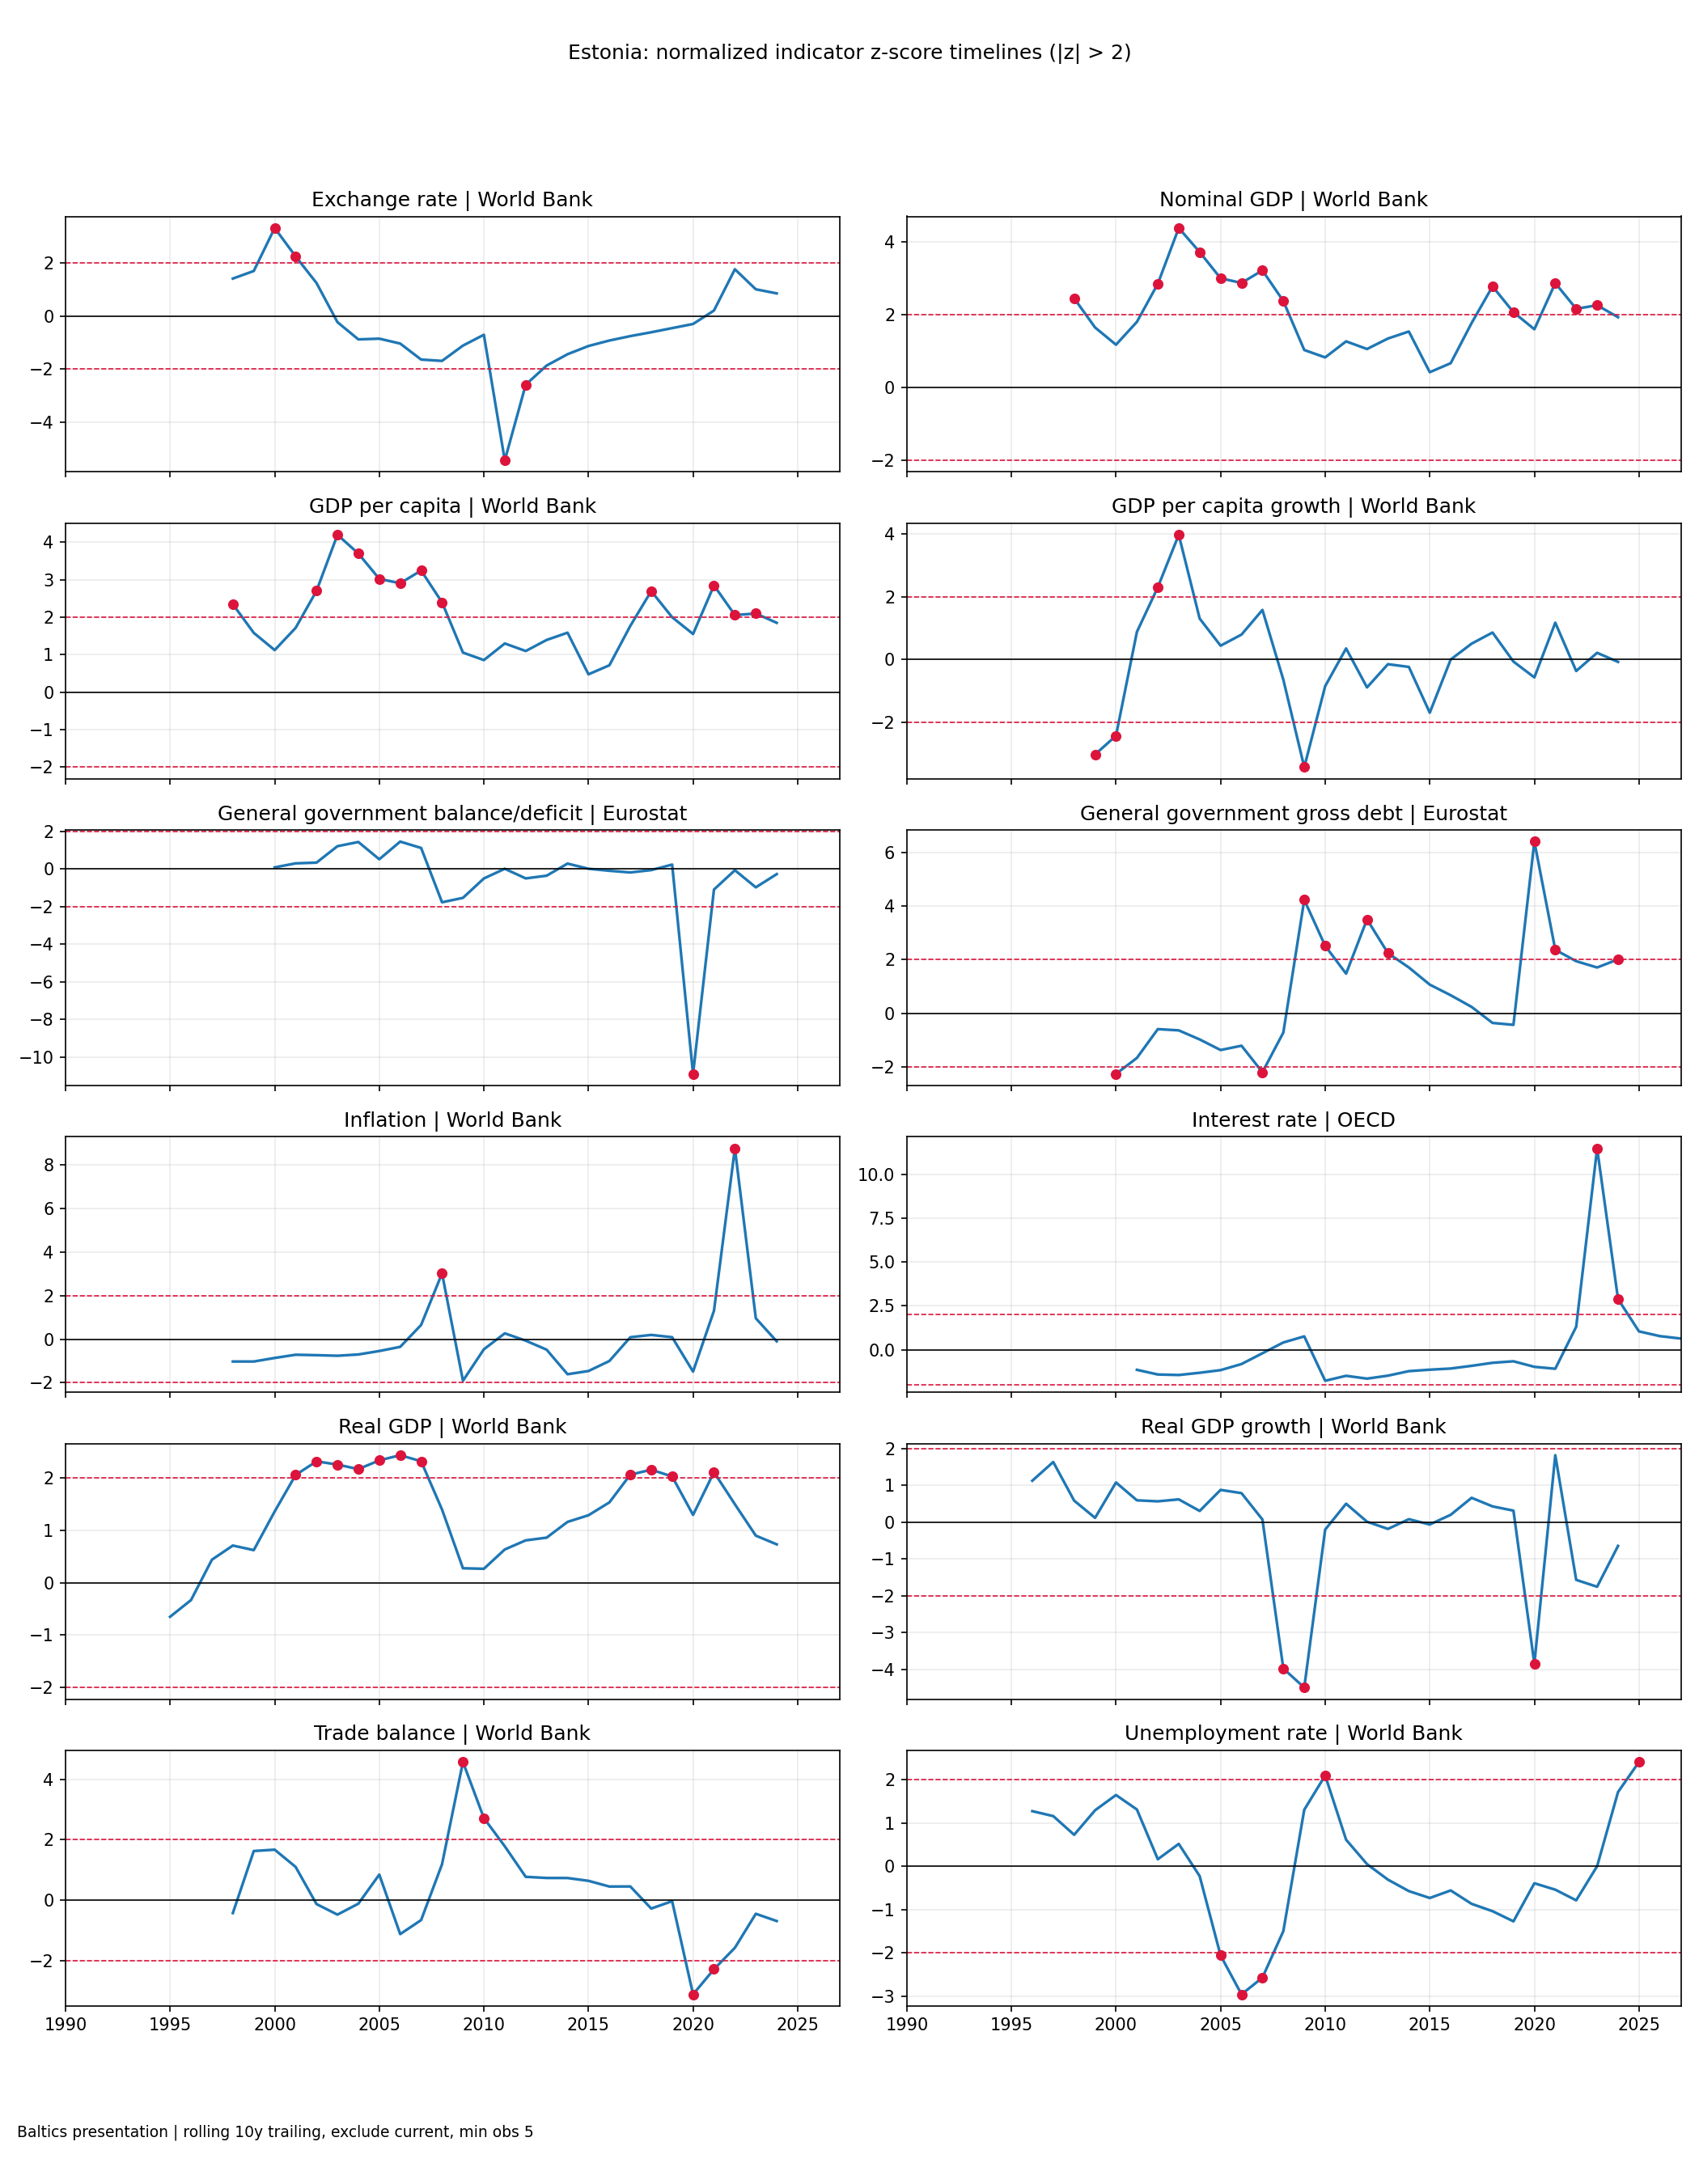

In [12]:
_lt_presentation_view = _render_country_rolling_section(
    "LT",
    view_name=presentation_view_config["view_name"],
    view_config=presentation_view_config,
)
_lv_presentation_view = _render_country_rolling_section(
    "LV",
    view_name=presentation_view_config["view_name"],
    view_config=presentation_view_config,
)
_ee_presentation_view = _render_country_rolling_section(
    "EE",
    view_name=presentation_view_config["view_name"],
    view_config=presentation_view_config,
)


## Methodology view

The methodology view keeps the same rolling normalization but turns on the richer typed notebook metadata so the rendered view exposes manifest, label, and section context beside the visuals.


### Lithuania

- Render: Lithuania | dynamic notebook | region Baltics methodology

- Normalization: Rolling trailing, 10y, exclude current, min obs 5

- Transformation: No transformation requested.

,country_code,country_display_name,render_origin,region_label,normalization,transformation,manifest_path,anomalies_path
0,LT,Lithuania,dynamic_notebook,Baltics methodology,"Rolling trailing, 10y, exclude current, min obs 5",No transformation requested.,/workspaces/da-ai-v2/bs2026_student_projects/A...,/workspaces/da-ai-v2/bs2026_student_projects/A...


...

#### Render manifest

,chart_type,status,file_path,render_origin,region_label,normalization_mode,config_slug,transformation_strategy_slug
0,zscore_heatmap,ok,/workspaces/da-ai-v2/bs2026_student_projects/A...,dynamic_notebook,Baltics methodology,rolling_trailing,mode_rolling_trailing__window_10__exclude_curr...,
1,zscore_timelines,ok,/workspaces/da-ai-v2/bs2026_student_projects/A...,dynamic_notebook,Baltics methodology,rolling_trailing,mode_rolling_trailing__window_10__exclude_curr...,


#### Chart labels

,indicator_id,indicator_label,source_label,indicator_source_label
0,exchange_rate_lcu_per_usd,Exchange rate,World Bank,Exchange rate | World Bank
1,gdp_current_usd,Nominal GDP,World Bank,Nominal GDP | World Bank
2,gdp_per_capita,GDP per capita,World Bank,GDP per capita | World Bank
3,general_government_balance_deficit_pct_gdp,General government balance/deficit,Eurostat,General government balance/deficit | Eurostat
4,general_government_gross_debt_pct_gdp,General government gross debt,Eurostat,General government gross debt | Eurostat
5,inflation_cpi_yoy,Inflation,World Bank,Inflation | World Bank
6,lending_interest_rate,Interest rate,OECD,Interest rate | OECD
7,real_gdp,Real GDP,World Bank,Real GDP | World Bank
8,trade_balance_pct_gdp,Trade balance,World Bank,Trade balance | World Bank
9,unemployment_rate,Unemployment rate,World Bank,Unemployment rate | World Bank


#### Chart artifacts

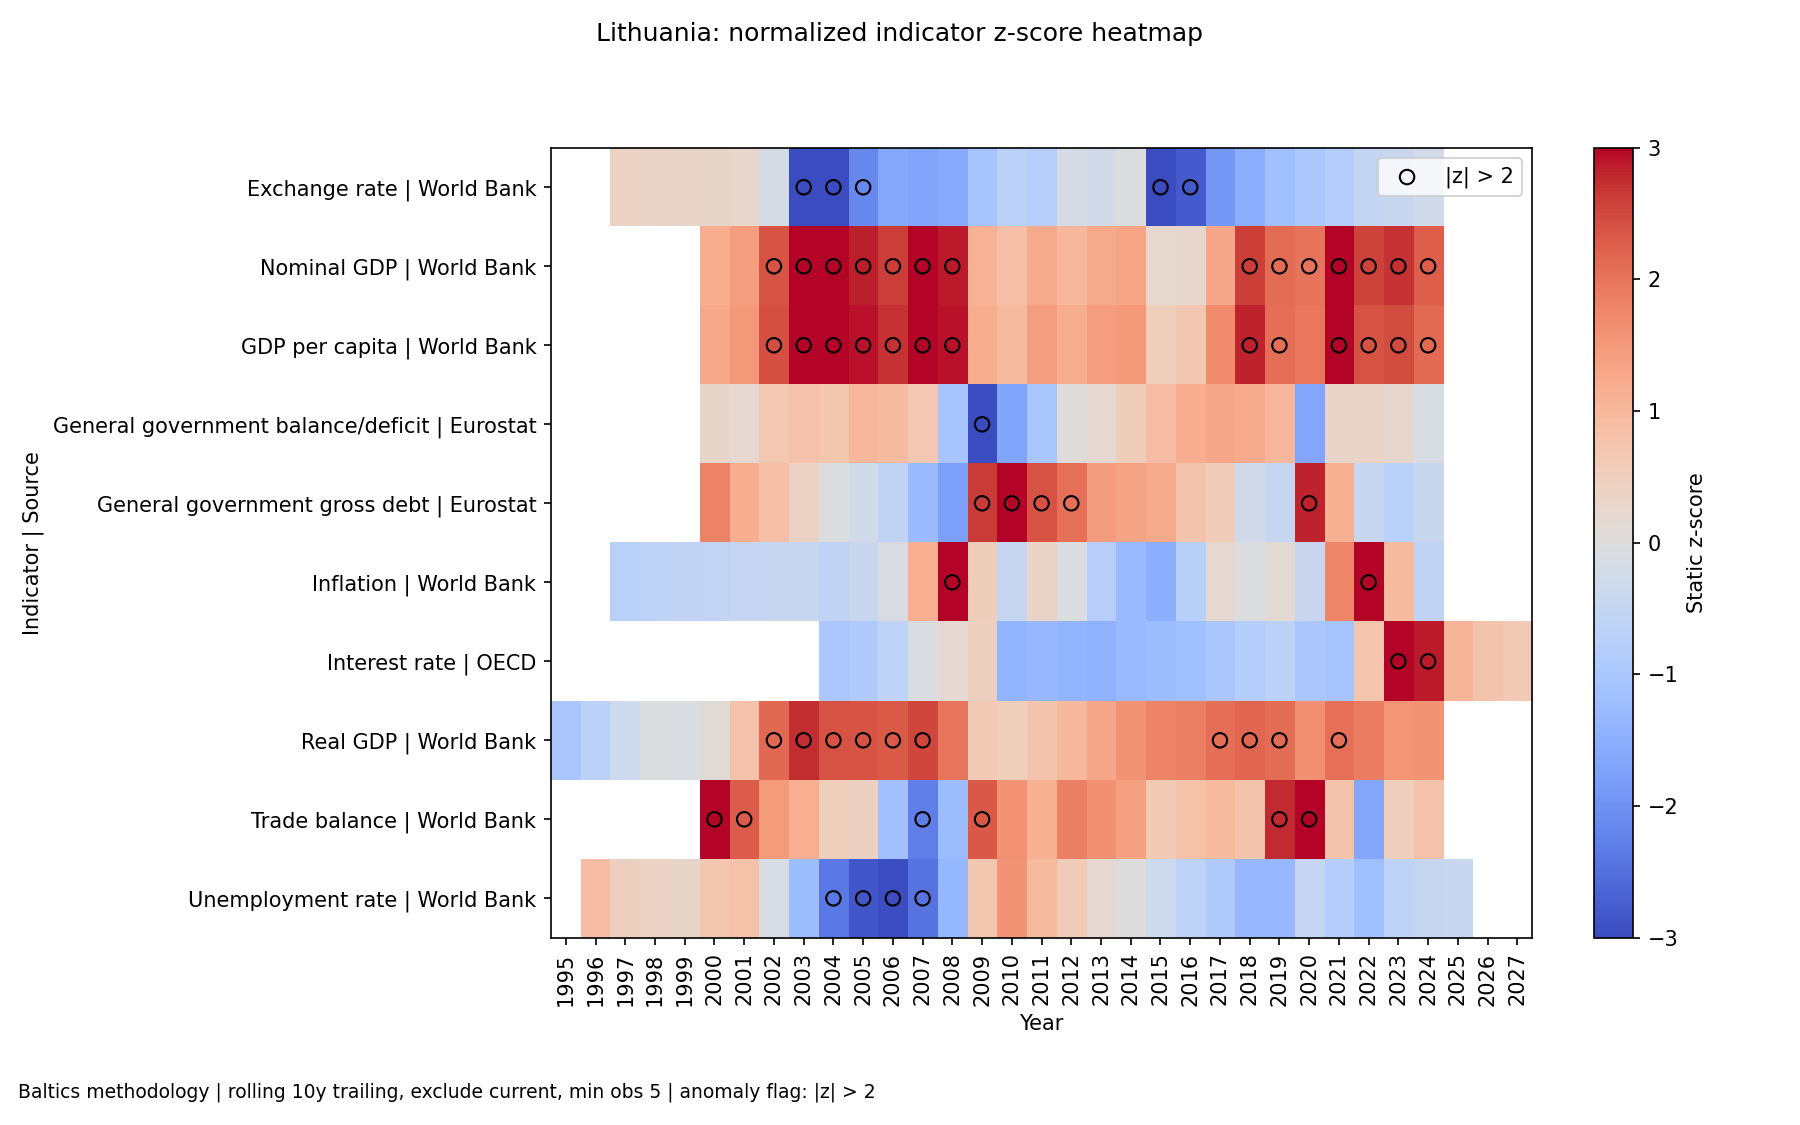

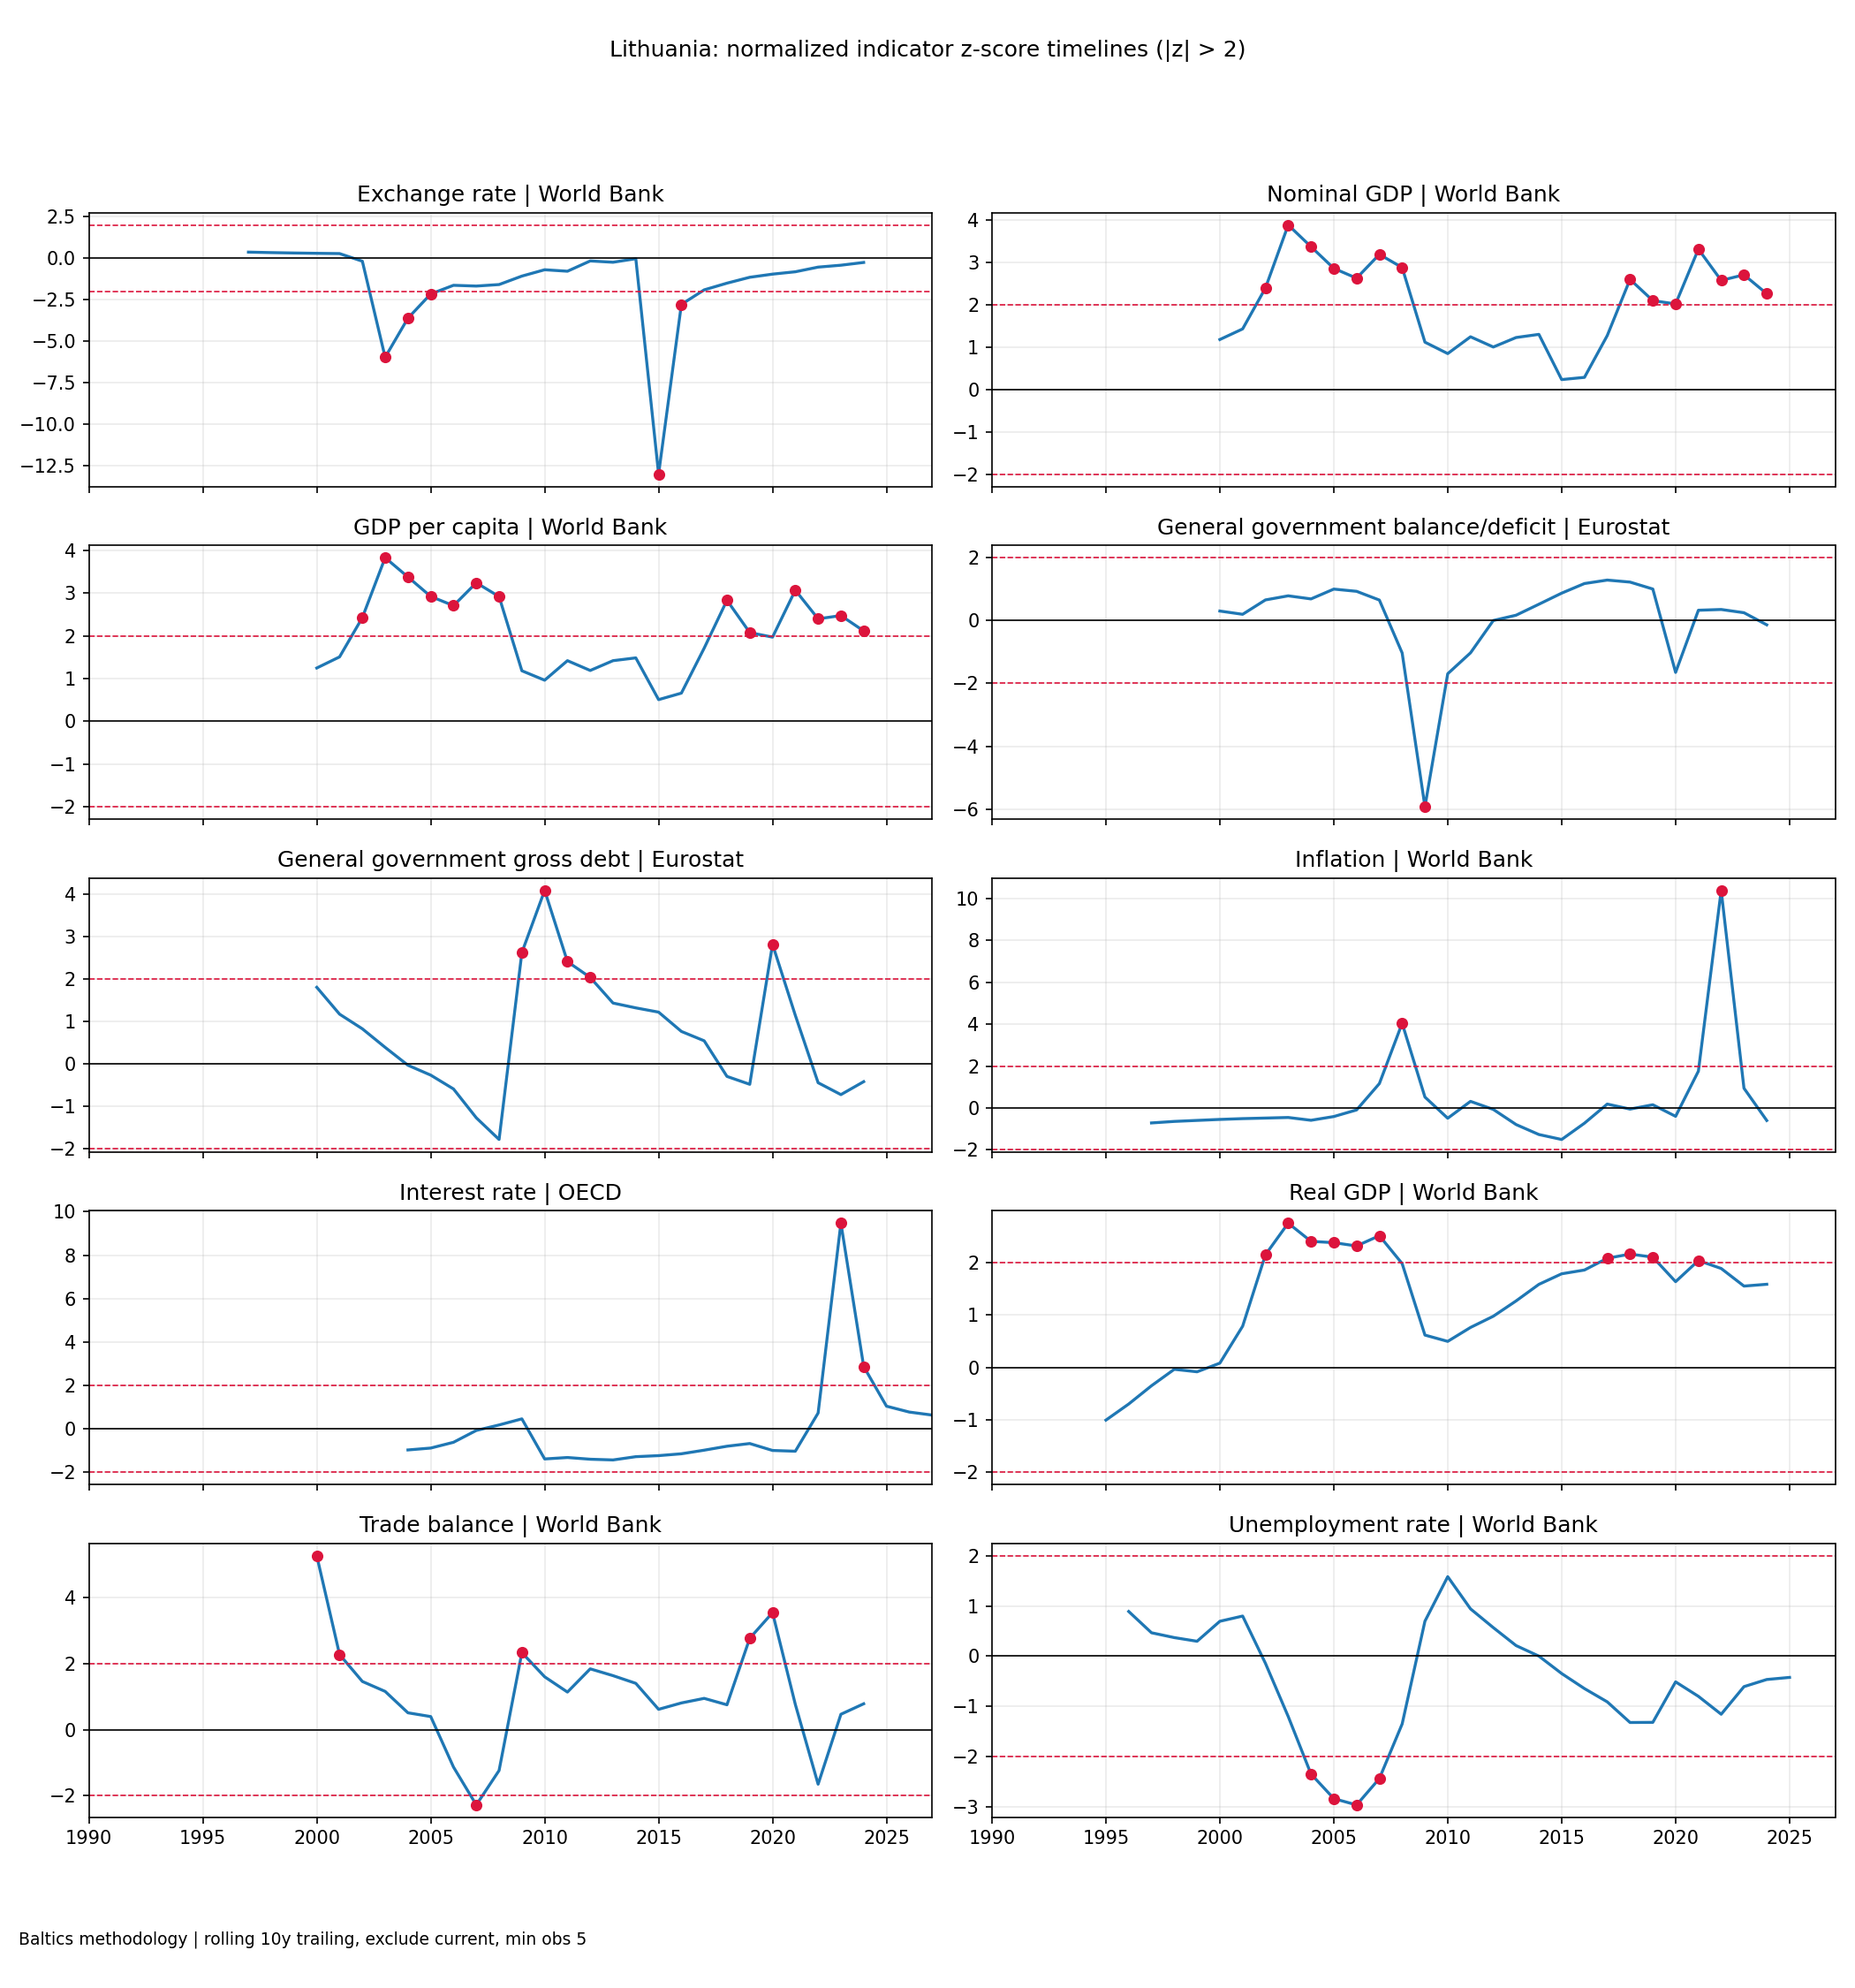

### Latvia

- Render: Latvia | dynamic notebook | region Baltics methodology

- Normalization: Rolling trailing, 10y, exclude current, min obs 5

- Transformation: No transformation requested.

,country_code,country_display_name,render_origin,region_label,normalization,transformation,manifest_path,anomalies_path
0,LV,Latvia,dynamic_notebook,Baltics methodology,"Rolling trailing, 10y, exclude current, min obs 5",No transformation requested.,/workspaces/da-ai-v2/bs2026_student_projects/A...,/workspaces/da-ai-v2/bs2026_student_projects/A...


...

#### Render manifest

,chart_type,status,file_path,render_origin,region_label,normalization_mode,config_slug,transformation_strategy_slug
0,zscore_heatmap,ok,/workspaces/da-ai-v2/bs2026_student_projects/A...,dynamic_notebook,Baltics methodology,rolling_trailing,mode_rolling_trailing__window_10__exclude_curr...,
1,zscore_timelines,ok,/workspaces/da-ai-v2/bs2026_student_projects/A...,dynamic_notebook,Baltics methodology,rolling_trailing,mode_rolling_trailing__window_10__exclude_curr...,


#### Chart labels

,indicator_id,indicator_label,source_label,indicator_source_label
0,exchange_rate_lcu_per_usd,Exchange rate,World Bank,Exchange rate | World Bank
1,gdp_current_usd,Nominal GDP,World Bank,Nominal GDP | World Bank
2,gdp_per_capita,GDP per capita,World Bank,GDP per capita | World Bank
3,general_government_balance_deficit_pct_gdp,General government balance/deficit,Eurostat,General government balance/deficit | Eurostat
4,general_government_gross_debt_pct_gdp,General government gross debt,Eurostat,General government gross debt | Eurostat
5,inflation_cpi_yoy,Inflation,World Bank,Inflation | World Bank
6,lending_interest_rate,Interest rate,Eurostat,Interest rate | Eurostat
7,real_gdp,Real GDP,World Bank,Real GDP | World Bank
8,trade_balance_pct_gdp,Trade balance,World Bank,Trade balance | World Bank
9,unemployment_rate,Unemployment rate,World Bank,Unemployment rate | World Bank


#### Chart artifacts

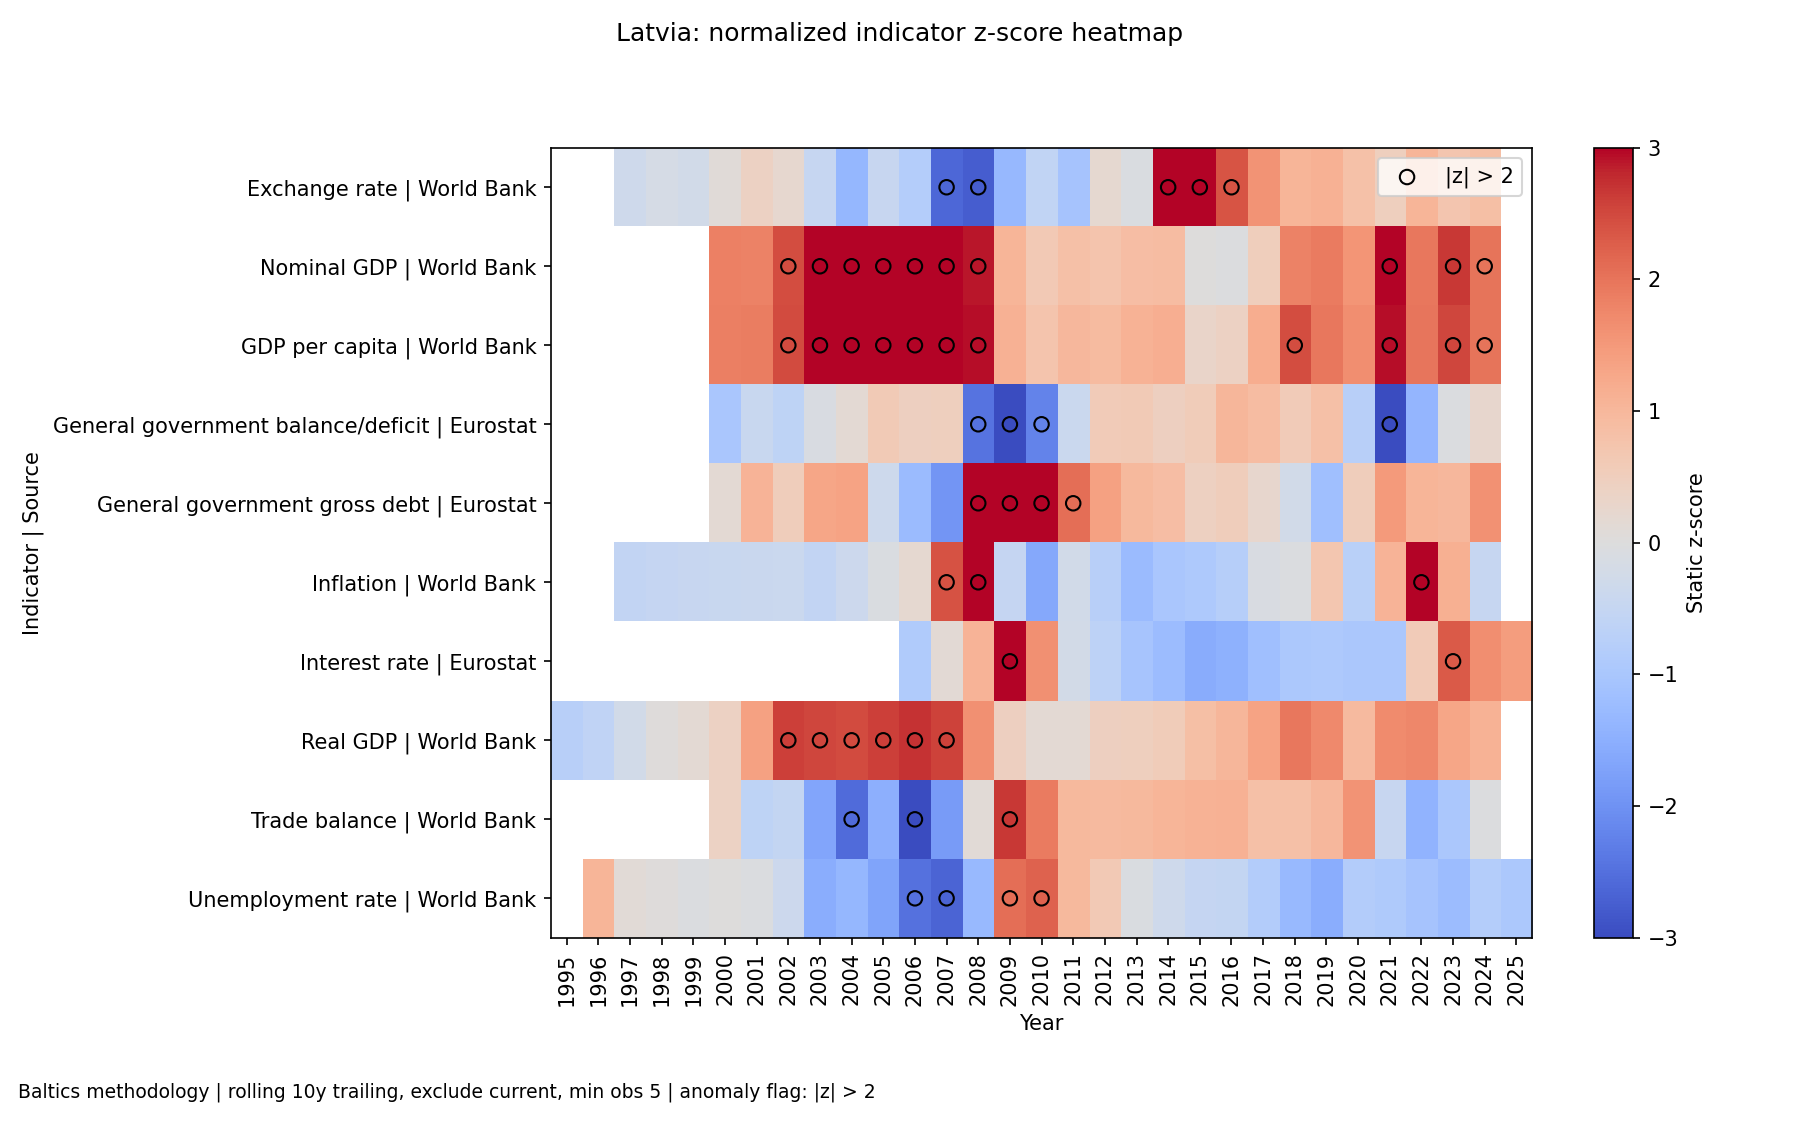

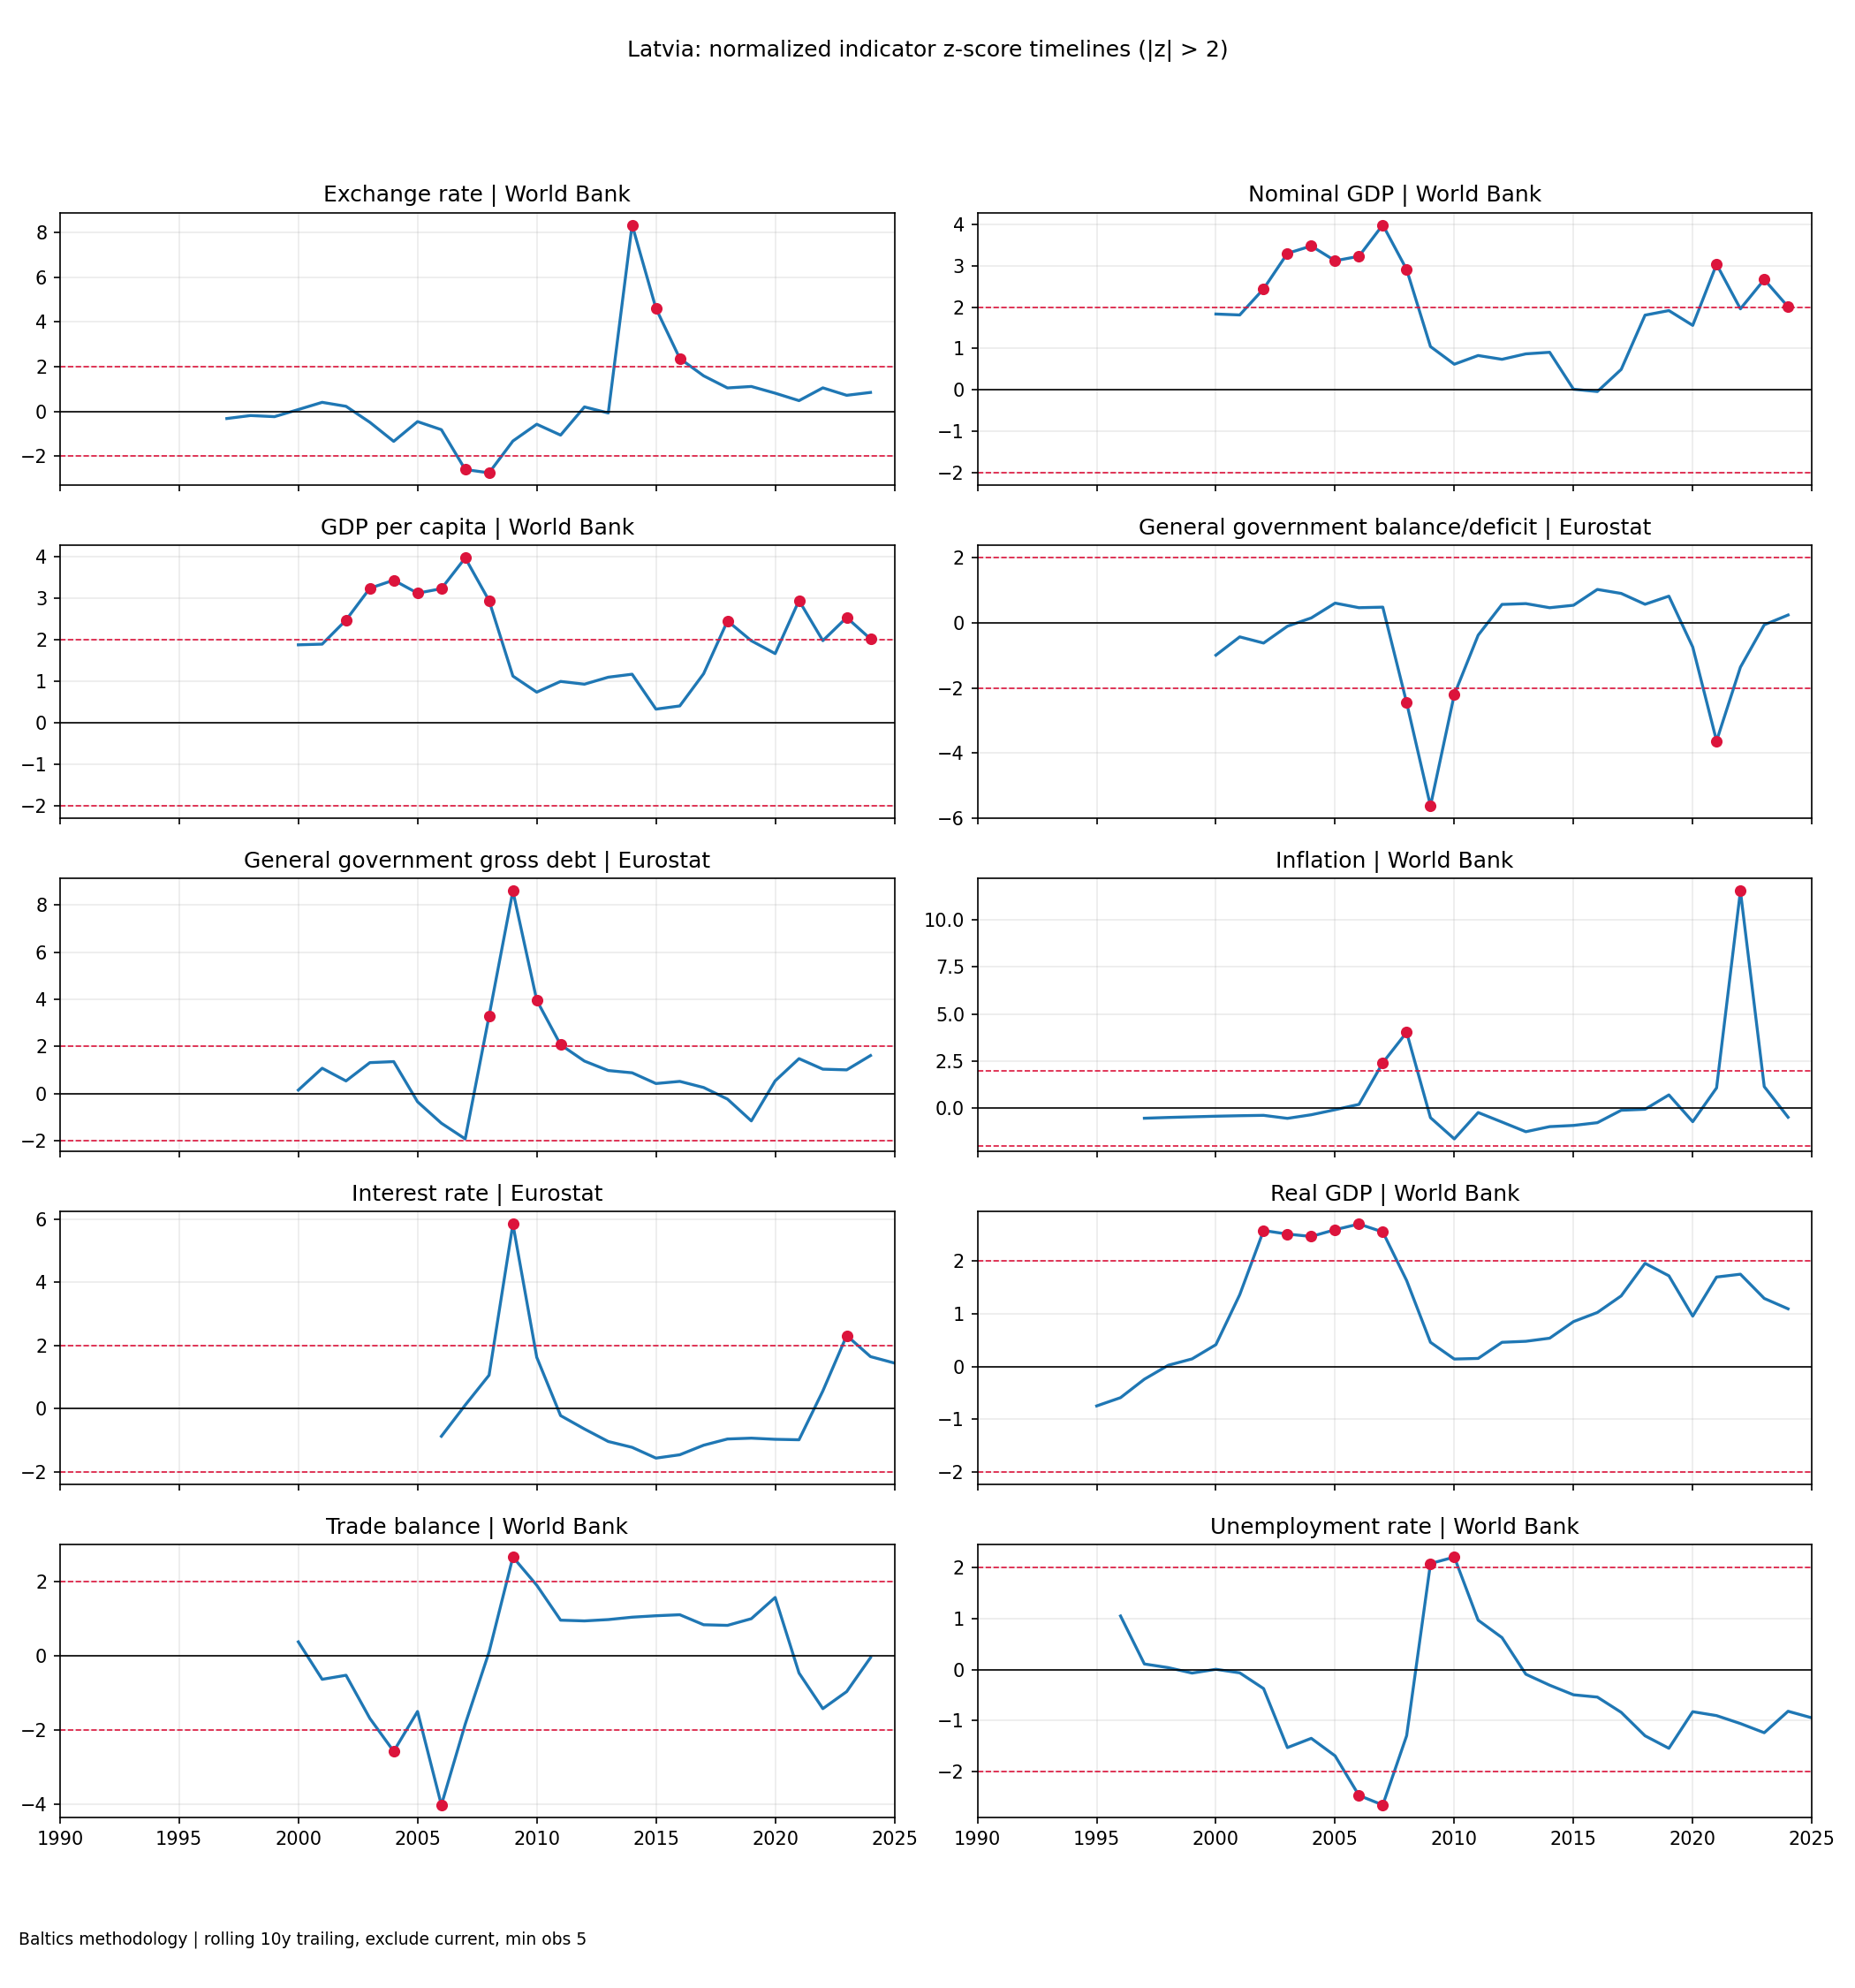

### Estonia

- Render: Estonia | dynamic notebook | region Baltics methodology

- Normalization: Rolling trailing, 10y, exclude current, min obs 5

- Transformation: No transformation requested.

,country_code,country_display_name,render_origin,region_label,normalization,transformation,manifest_path,anomalies_path
0,EE,Estonia,dynamic_notebook,Baltics methodology,"Rolling trailing, 10y, exclude current, min obs 5",No transformation requested.,/workspaces/da-ai-v2/bs2026_student_projects/A...,/workspaces/da-ai-v2/bs2026_student_projects/A...


...

#### Render manifest

,chart_type,status,file_path,render_origin,region_label,normalization_mode,config_slug,transformation_strategy_slug
0,zscore_heatmap,ok,/workspaces/da-ai-v2/bs2026_student_projects/A...,dynamic_notebook,Baltics methodology,rolling_trailing,mode_rolling_trailing__window_10__exclude_curr...,
1,zscore_timelines,ok,/workspaces/da-ai-v2/bs2026_student_projects/A...,dynamic_notebook,Baltics methodology,rolling_trailing,mode_rolling_trailing__window_10__exclude_curr...,


#### Chart labels

,indicator_id,indicator_label,source_label,indicator_source_label
0,exchange_rate_lcu_per_usd,Exchange rate,World Bank,Exchange rate | World Bank
1,gdp_current_usd,Nominal GDP,World Bank,Nominal GDP | World Bank
2,gdp_per_capita,GDP per capita,World Bank,GDP per capita | World Bank
3,general_government_balance_deficit_pct_gdp,General government balance/deficit,Eurostat,General government balance/deficit | Eurostat
4,general_government_gross_debt_pct_gdp,General government gross debt,Eurostat,General government gross debt | Eurostat
5,inflation_cpi_yoy,Inflation,World Bank,Inflation | World Bank
6,lending_interest_rate,Interest rate,IMF,Interest rate | IMF
7,real_gdp,Real GDP,World Bank,Real GDP | World Bank
8,trade_balance_pct_gdp,Trade balance,World Bank,Trade balance | World Bank
9,unemployment_rate,Unemployment rate,World Bank,Unemployment rate | World Bank


#### Chart artifacts

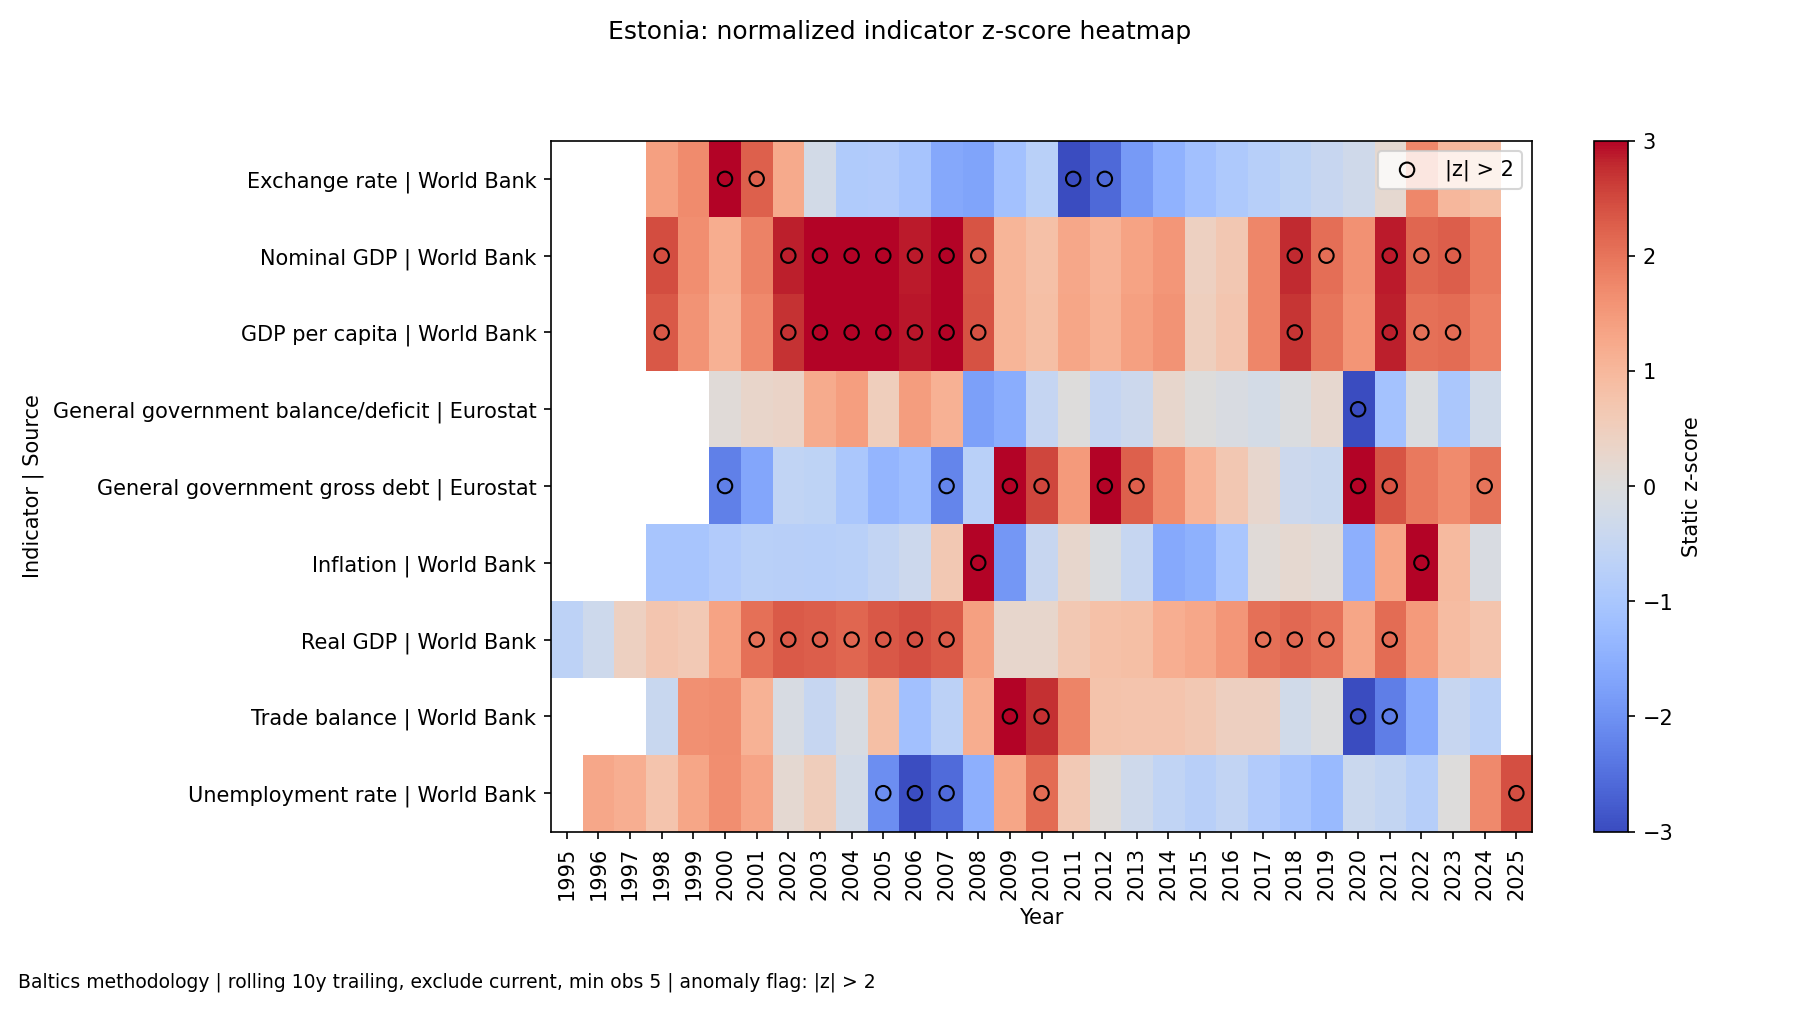

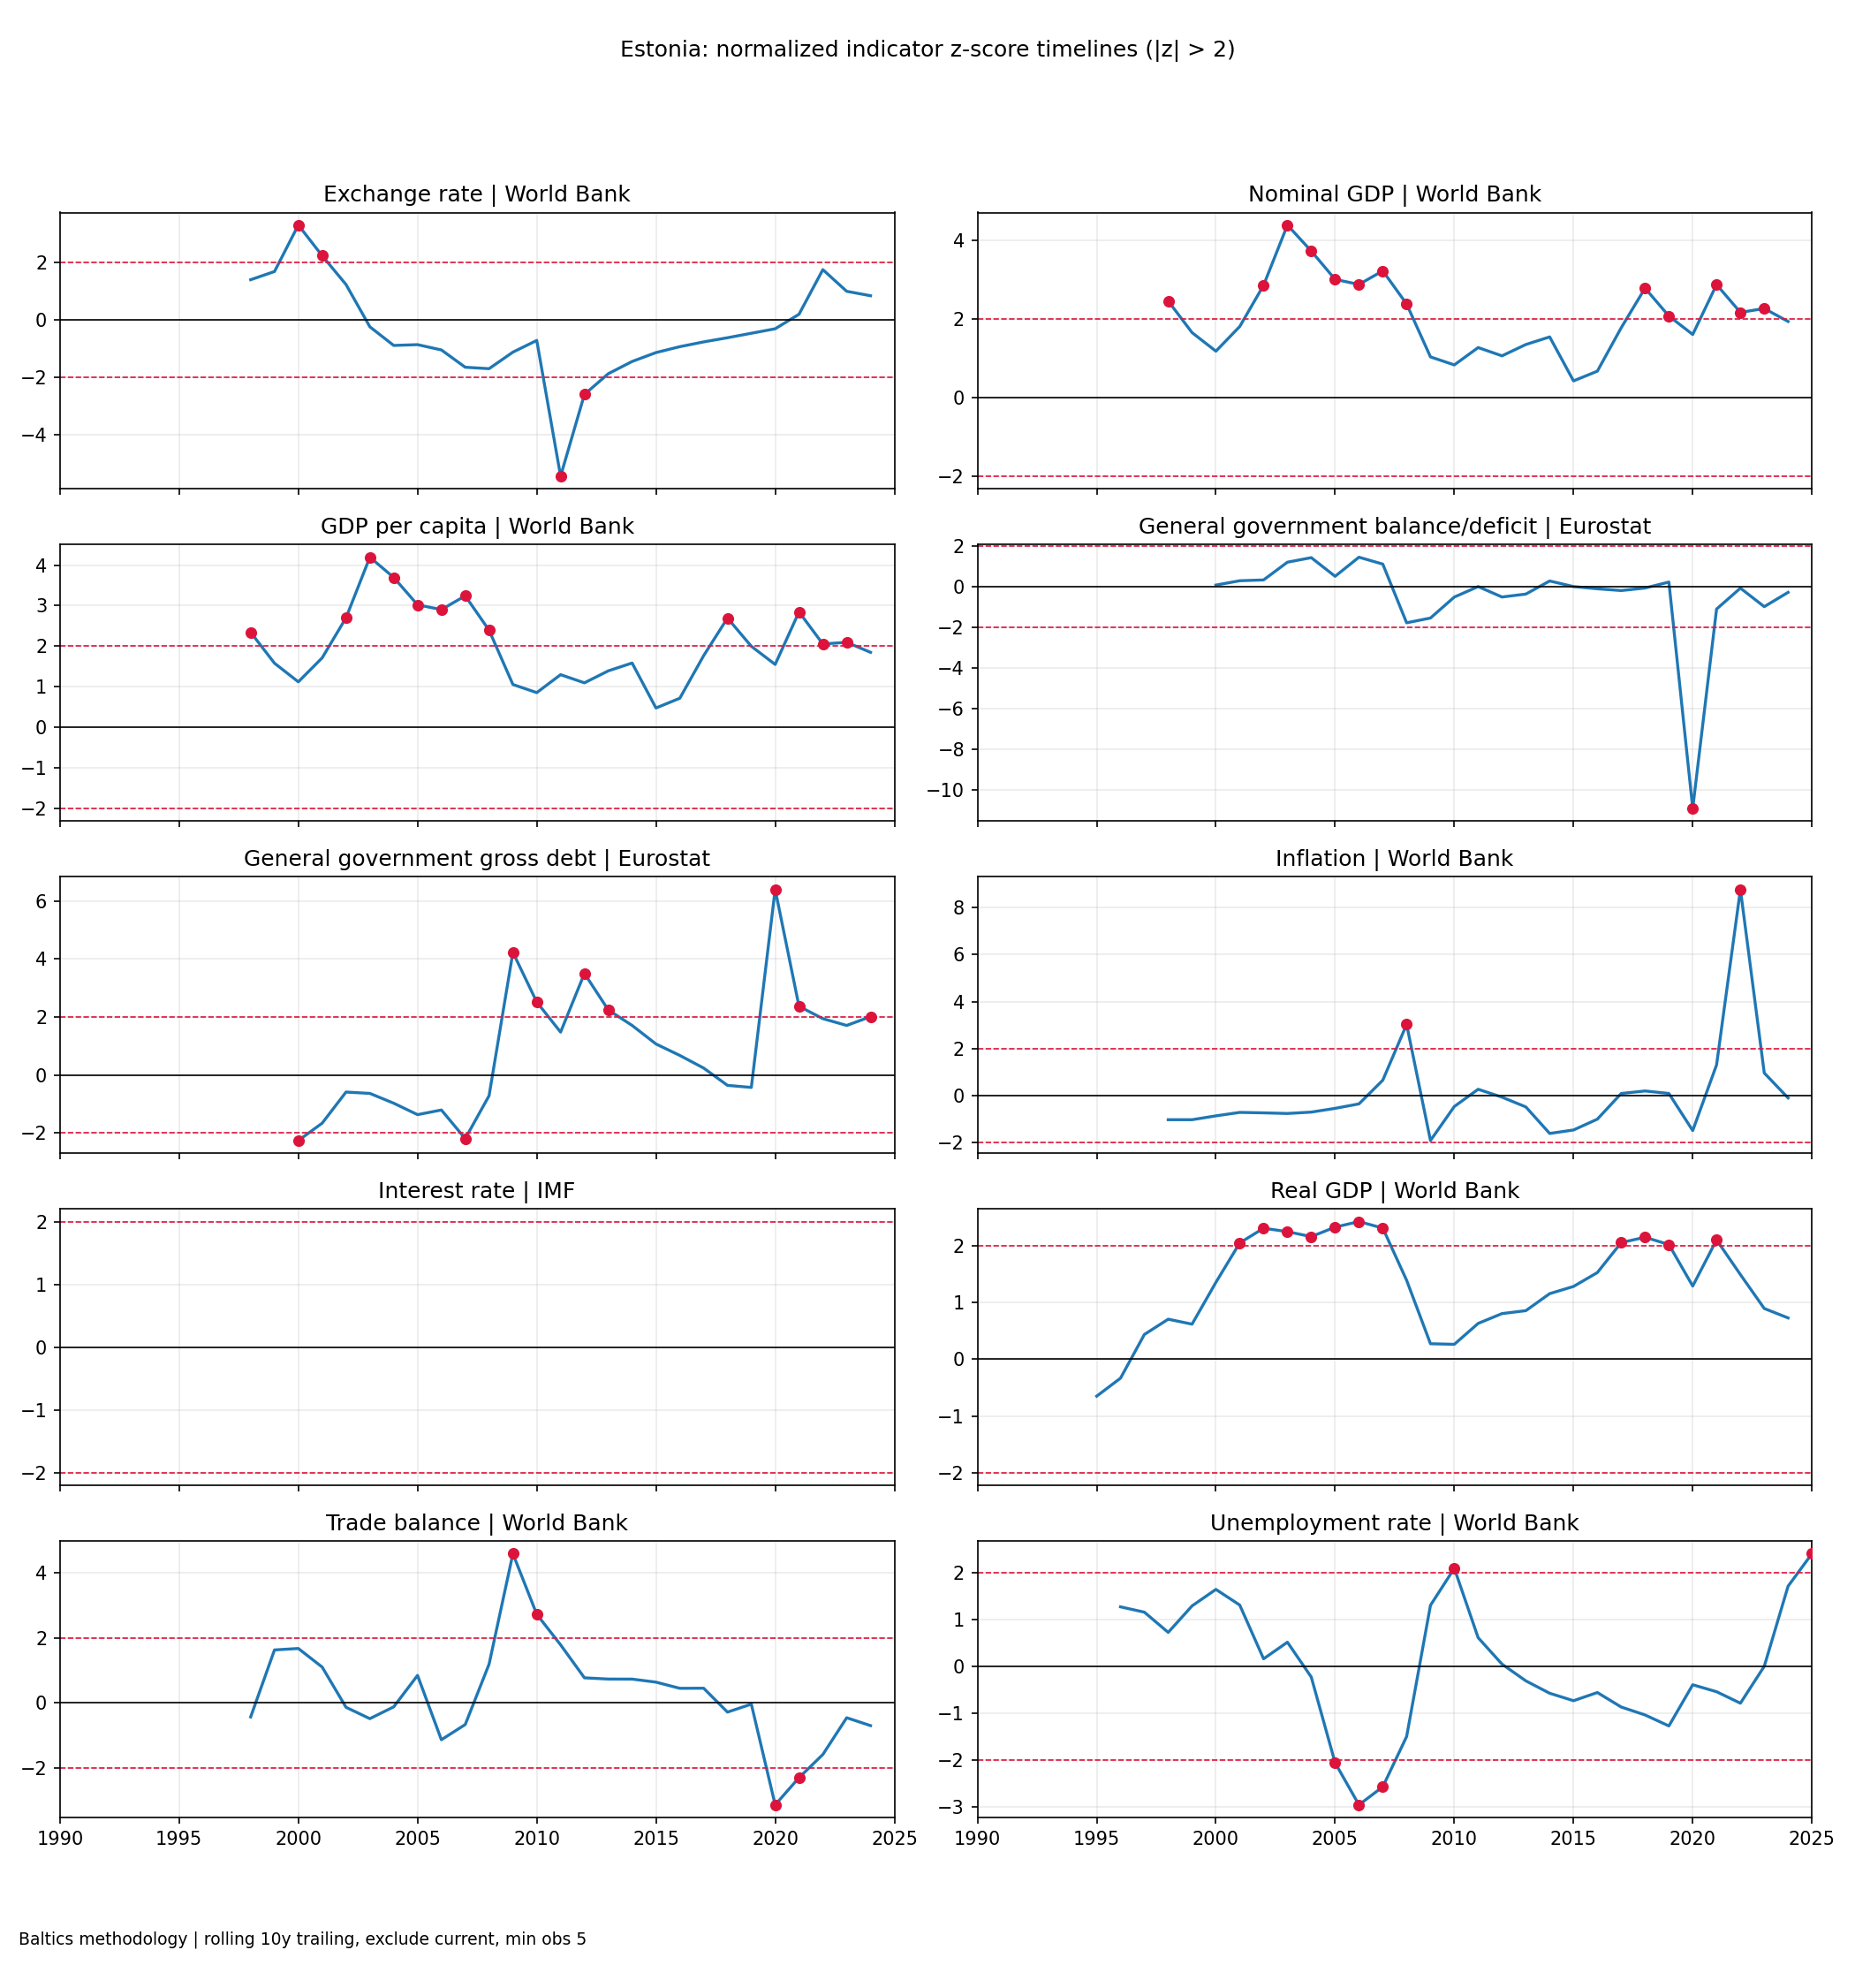

In [13]:
_lt_methodology_view = _render_country_rolling_section(
    "LT",
    view_name=methodology_view_config["view_name"],
    view_config=methodology_view_config,
)
_lv_methodology_view = _render_country_rolling_section(
    "LV",
    view_name=methodology_view_config["view_name"],
    view_config=methodology_view_config,
)
_ee_methodology_view = _render_country_rolling_section(
    "EE",
    view_name=methodology_view_config["view_name"],
    view_config=methodology_view_config,
)


## Optional nominal GDP growth variant

Set `include_nominal_gdp=True` when you want to inspect the additive nominal-growth transform without changing the default presentation or methodology configs.


### Lithuania

- Render: Lithuania | dynamic notebook | region Baltics_nominal

- Normalization: Rolling trailing, 10y, exclude current, min obs 5

- Transformation: Transformation active: Nominal GDP growth, GDP per capita growth, Real GDP growth

,country_code,country_display_name,render_origin,region_label,normalization,transformation,manifest_path,anomalies_path
0,LT,Lithuania,dynamic_notebook,Baltics_nominal,"Rolling trailing, 10y, exclude current, min obs 5","Transformation active: Nominal GDP growth, GDP...",/workspaces/da-ai-v2/bs2026_student_projects/A...,/workspaces/da-ai-v2/bs2026_student_projects/A...


#### Indicator sections

,group_name,indicator_ids
0,Context,general_government_gross_debt_pct_gdp
1,Growth narrative,"real_gdp_yoy_log_pct, gdp_per_capita_yoy_log_p..."
2,Remaining,"exchange_rate_lcu_per_usd, gdp_current_usd, gd..."


#### Chart artifacts

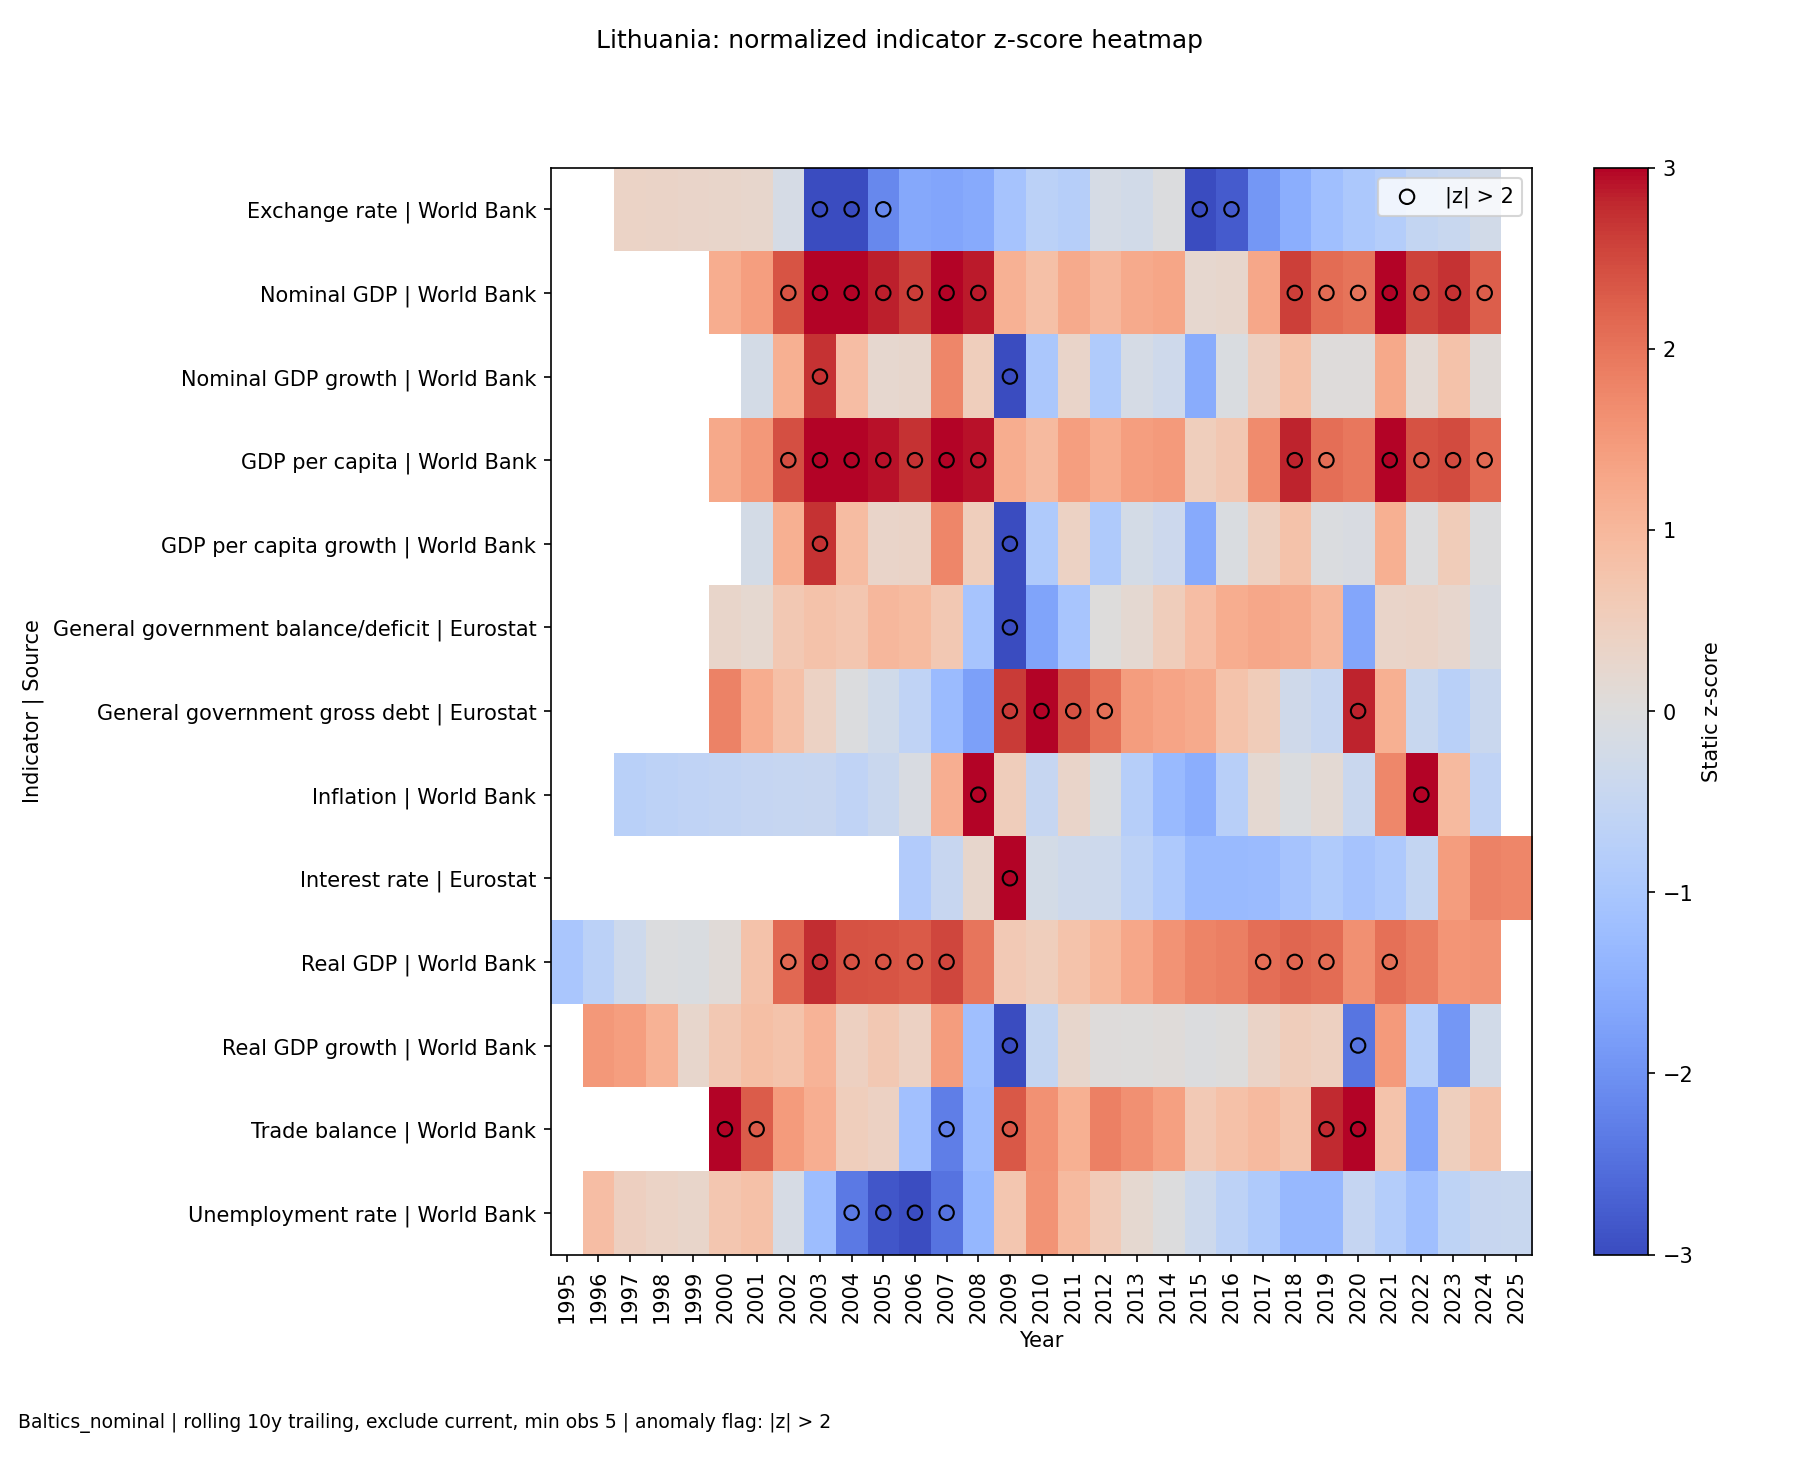

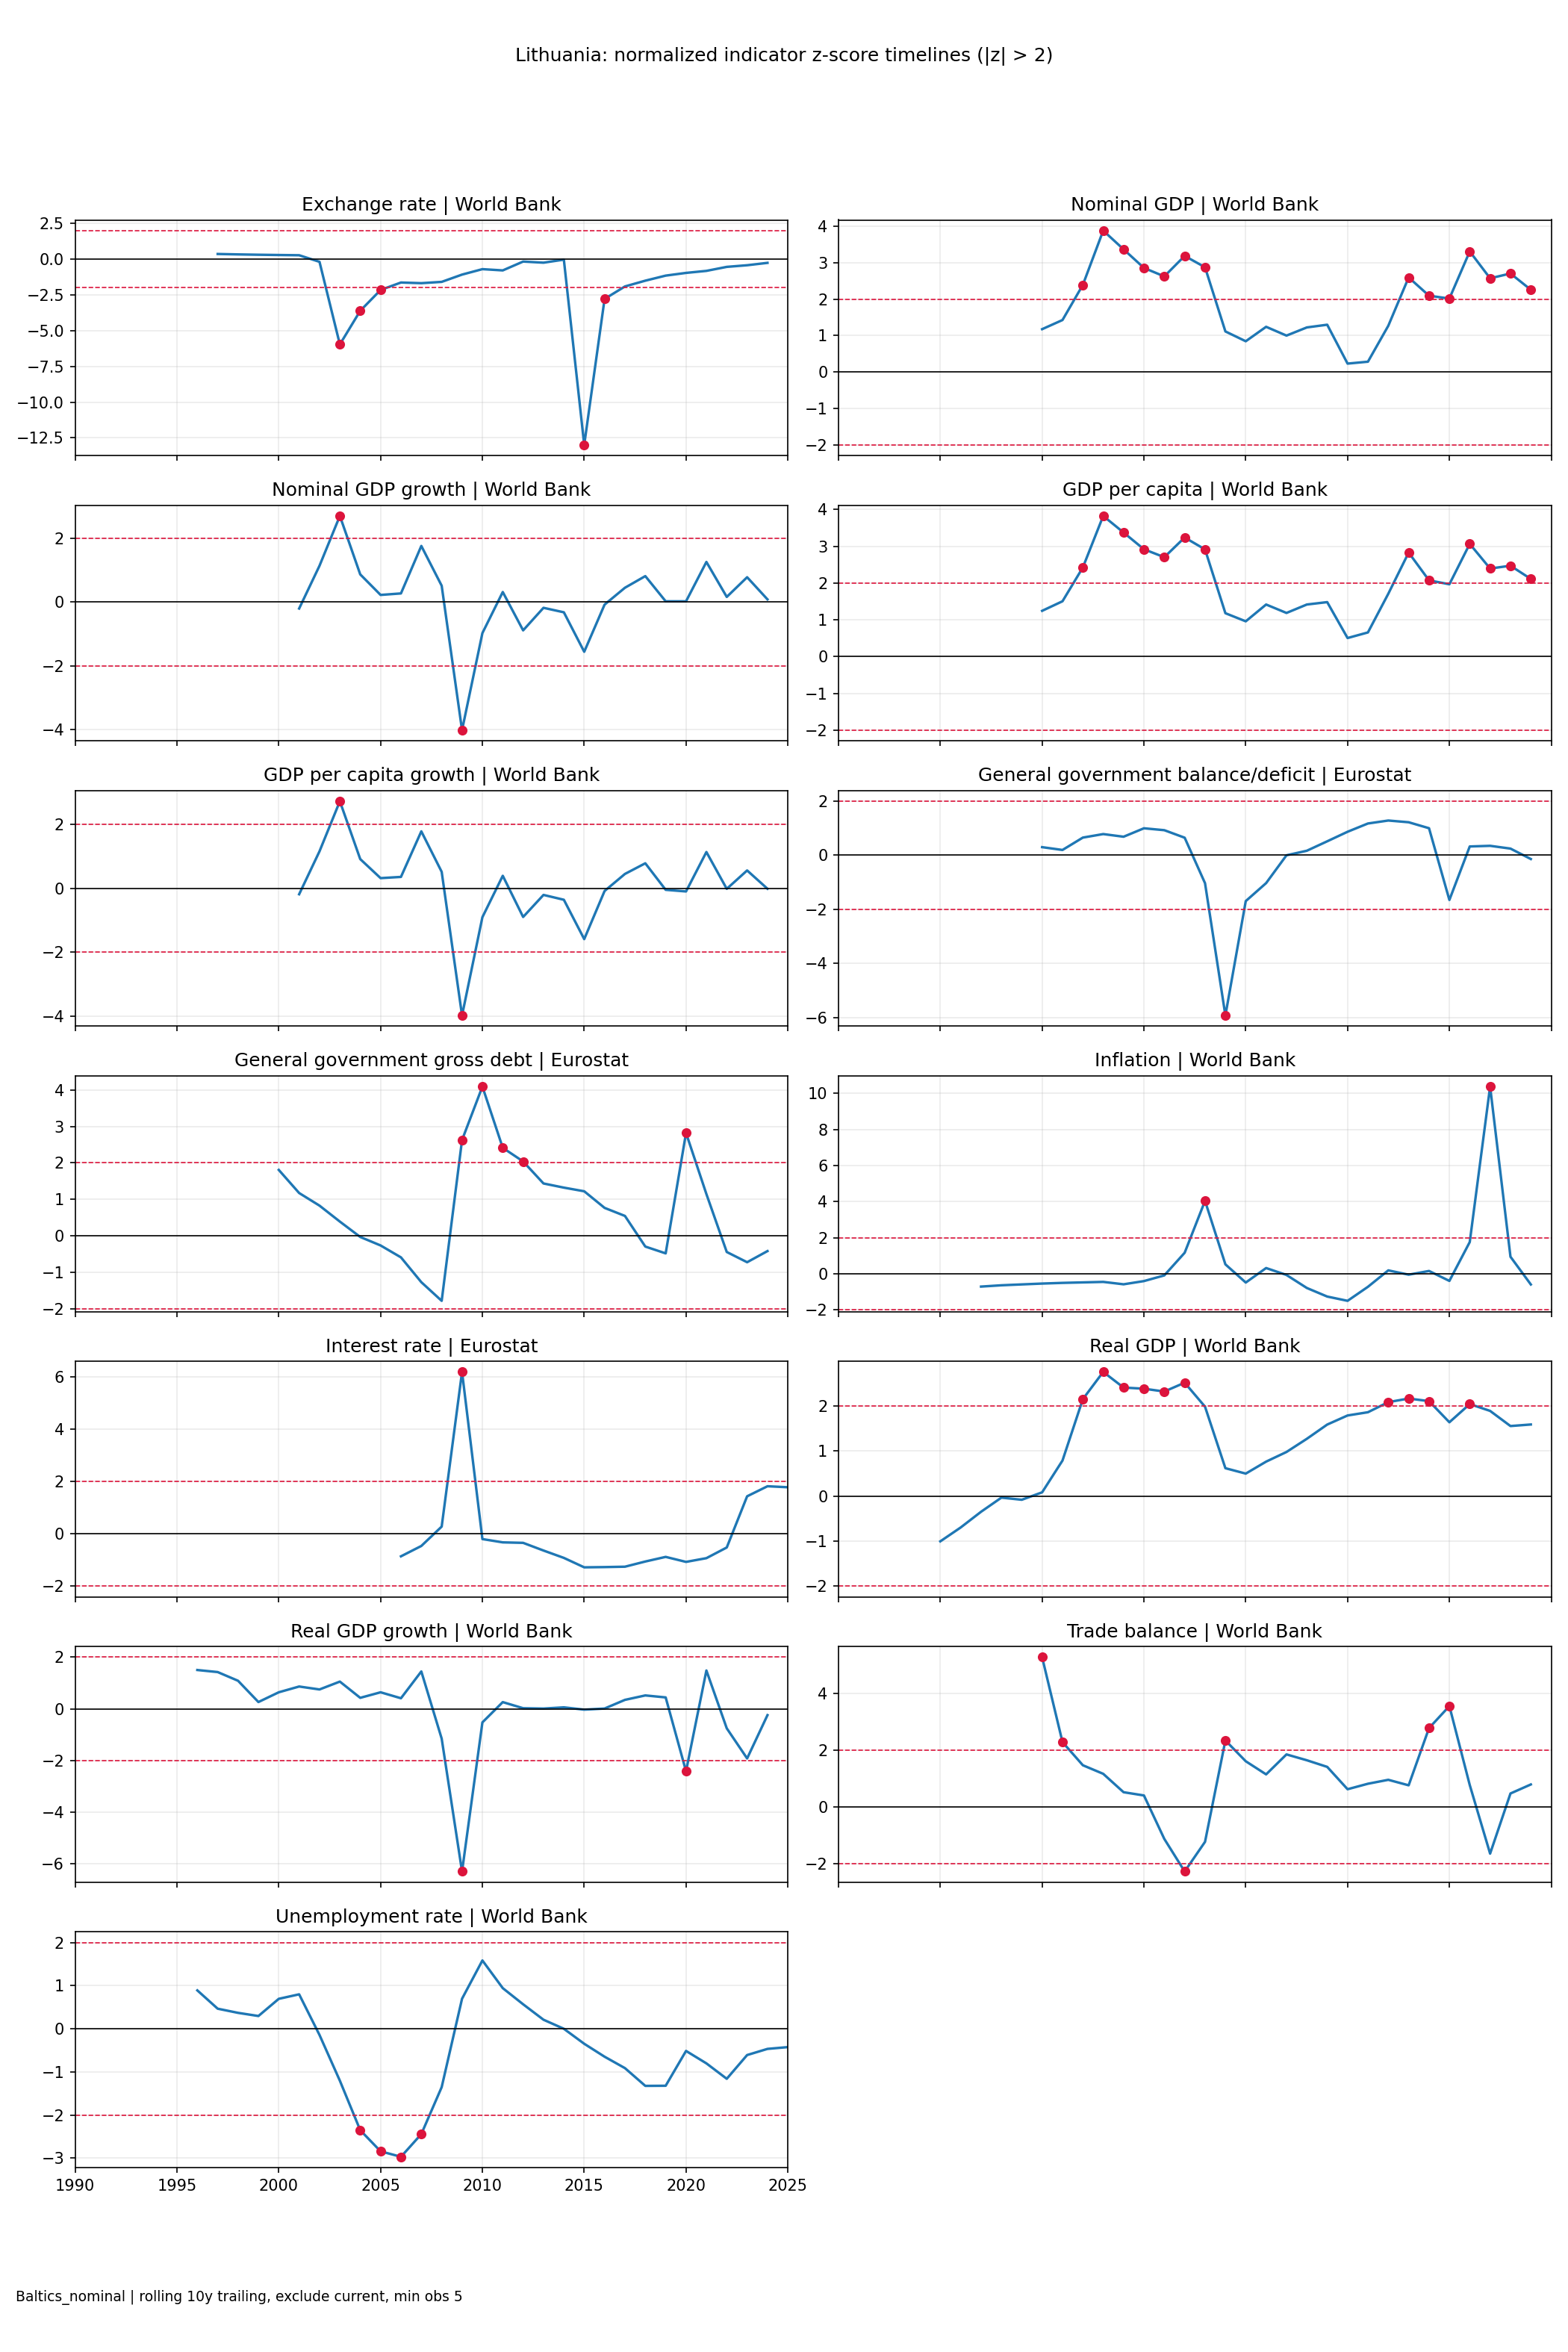

In [14]:
nominal_presentation_view_config = deepcopy(presentation_view_config)
nominal_presentation_view_config["view_name"] = "nominal_view"
nominal_presentation_view_config["region_label"] = "Baltics_nominal"
nominal_presentation_view_config["transformation_strategy"] = (
    _build_recommended_gdp_growth_transformation_strategy(include_nominal_gdp=True)
)

_lt_presentation_nominal_view = _render_country_rolling_section(
    "LT",
    view_name=nominal_presentation_view_config["view_name"],
    view_config=nominal_presentation_view_config,
)
